# Exploración Inicial — Señales EEG/EMG

Este notebook analiza el dataset `datos_eeg_emg.csv` generado desde `Data.txt`.

**Estructura del dataset:**
| Columna | Tipo | Descripción |
|---------|------|-------------|
| `Tiempo_s` | float | Vector de tiempo en segundos (0.001 s de paso → 1000 Hz) |
| `EEG_1` | float | Canal EEG principal |
| `EEG_2` | float | Canal EEG secundario |
| `EMG_1..4` | float | Canales EMG musculares (4 canales) |

**Canales clave según el pipeline:**
- Para detección de **marcadores de movimiento**: un canal **EMG** (burst detector)
- Para análisis de **BP y desincronización beta**: los canales **EEG**

> **Nota reunión 09-04:** el pipeline es → detectar bursts EMG → usar como marcadores → cortar EEG → buscar BP (onda lenta pre-movimiento) y caída en banda Beta (13–30 Hz)

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.stats import kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 4)

DATA_PATH = '../data/datos_eeg_emg.csv'
SRATE = 1000  # Hz

## 1. Carga y descripción general

In [124]:
df = pd.read_csv(DATA_PATH)

print(f'Muestras  : {len(df):,}')
print(f'Columnas  : {list(df.columns)}')
print(f'Duración  : {df.Tiempo_s.iloc[-1]:.1f} s  ({df.Tiempo_s.iloc[-1]/60:.1f} min)')
print(f'Frec.     : {SRATE} Hz')
print()

df.describe().round(4)

Muestras  : 304,011
Columnas  : ['Tiempo_s', 'EEG_1', 'EEG_2', 'EMG_1', 'EMG_2', 'EMG_3', 'EMG_4', 'EMG_5', 'EMG_6']
Duración  : 304.0 s  (5.1 min)
Frec.     : 1000 Hz



,Tiempo_s,EEG_1,EEG_2,EMG_1,EMG_2,EMG_3,EMG_4,EMG_5,EMG_6
count,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000
mean,152.0050,0.2200,0.4410,-0.0117,-0.0239,-0.0161,-0.0213,-0.0209,-0.0251
std,87.7606,0.2592,0.4052,0.0241,0.0198,0.0075,0.0118,0.0024,0.0027
min,0.0000,-1.5869,-1.9883,-0.6875,-0.8919,-0.2200,-0.4557,-0.0704,-0.1778
25%,76.0025,0.0638,0.1973,-0.0137,-0.0253,-0.0172,-0.0225,-0.0217,-0.0261
50%,152.0050,0.2189,0.3779,-0.0115,-0.0236,-0.0158,-0.0210,-0.0207,-0.0249
75%,228.0075,0.3764,0.5962,-0.0100,-0.0226,-0.0150,-0.0201,-0.0199,-0.0240
max,304.0100,1.6181,2.6732,0.8581,0.5395,0.5102,0.7209,0.0273,0.0552


## 2. Señal completa — todos los canales

Vista rápida para detectar artefactos, saturaciones o canales ruidosos.

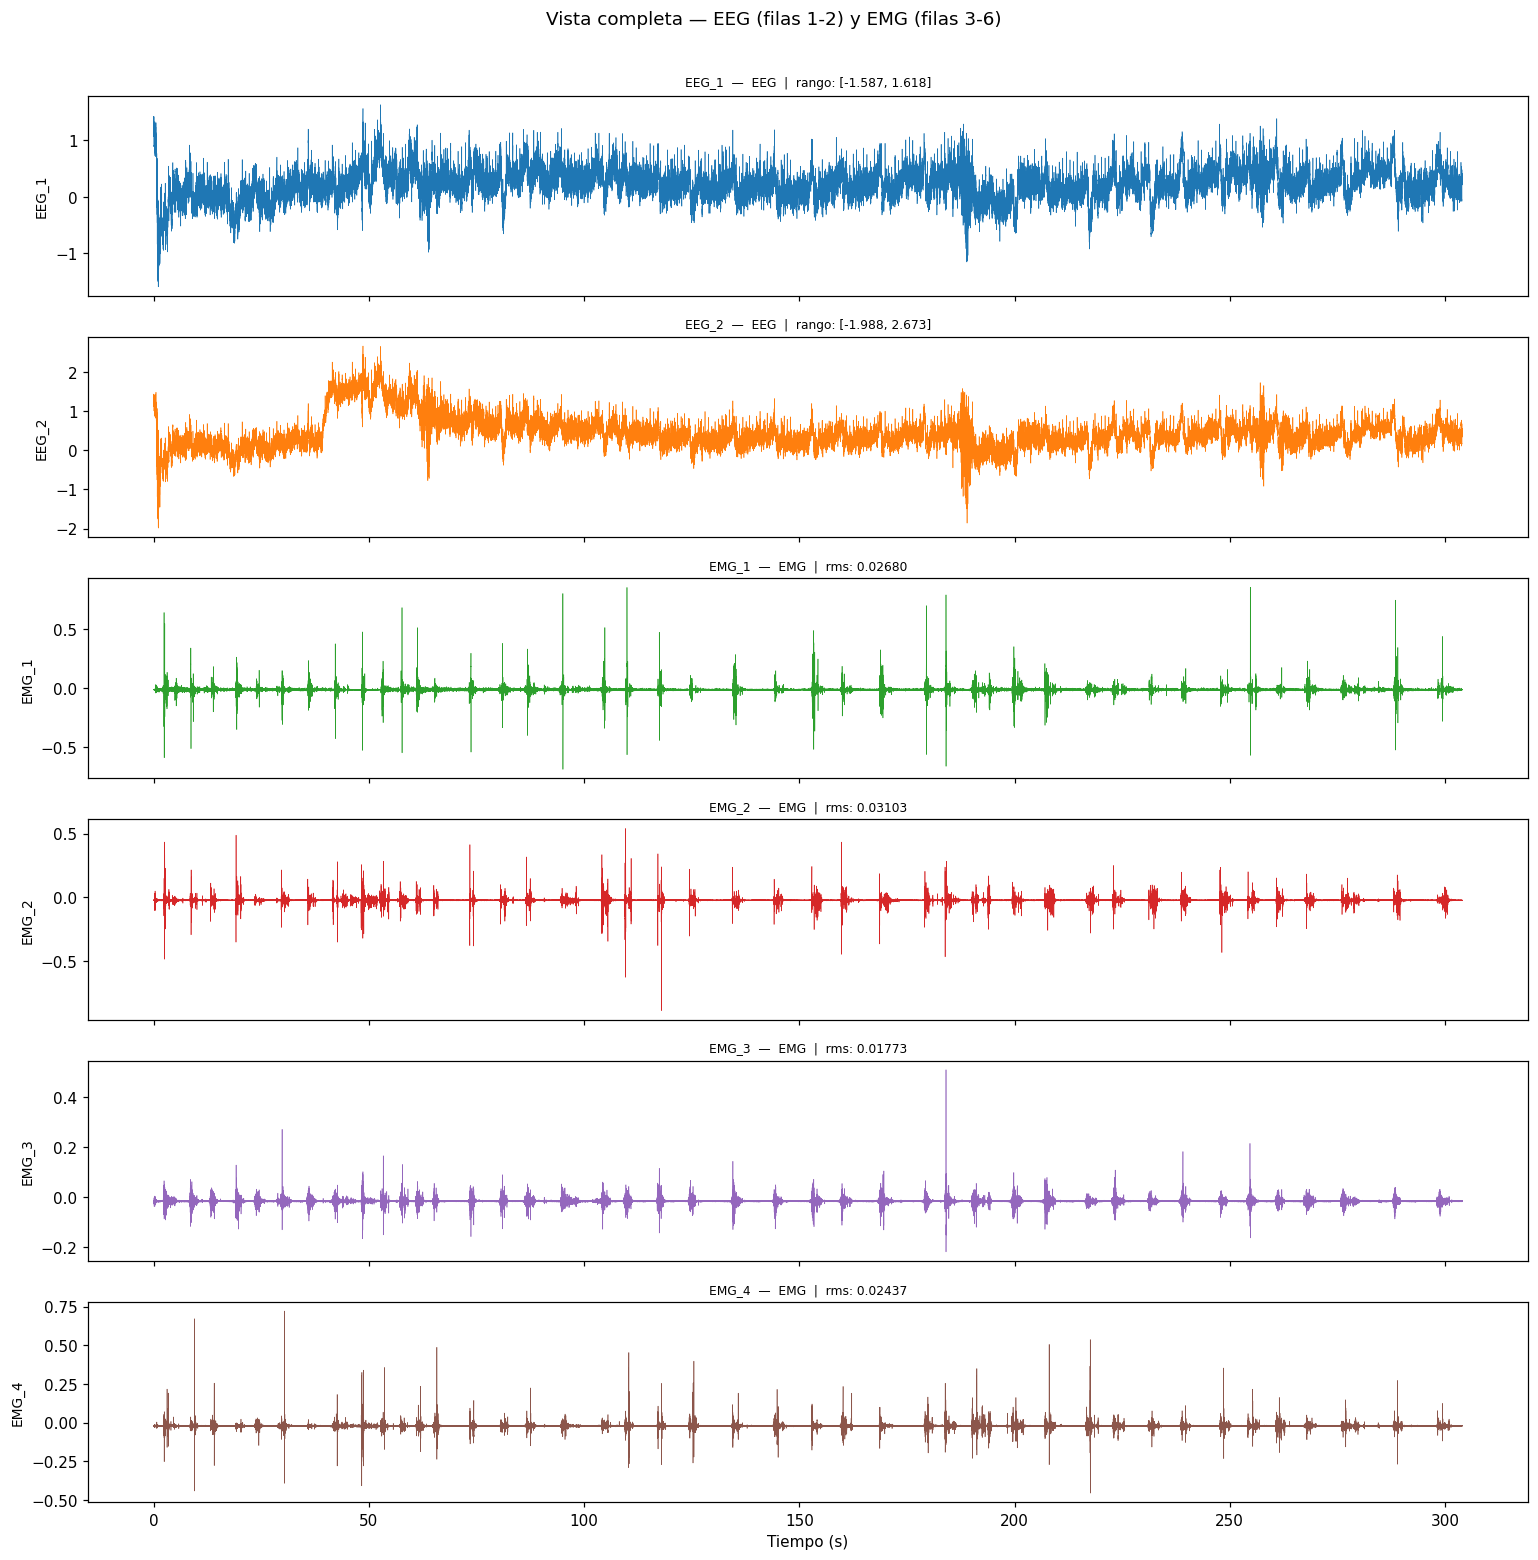

In [125]:
eeg_cols = ['EEG_1', 'EEG_2']
emg_cols = ['EMG_1', 'EMG_2', 'EMG_3', 'EMG_4']
t = df['Tiempo_s'].values

fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

colors_eeg = ['#1f77b4', '#ff7f0e']
colors_emg = ['#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(eeg_cols):
    axes[i].plot(t, df[col].values, color=colors_eeg[i], lw=0.4)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].set_title(f'{col}  —  EEG  |  rango: [{df[col].min():.3f}, {df[col].max():.3f}]', fontsize=8)

for j, col in enumerate(emg_cols):
    axes[j+2].plot(t, df[col].values, color=colors_emg[j], lw=0.4)
    axes[j+2].set_ylabel(col, fontsize=9)
    axes[j+2].set_title(f'{col}  —  EMG  |  rms: {np.sqrt(np.mean(df[col].values**2)):.5f}', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle('Vista completa — EEG (filas 1-2) y EMG (filas 3-6)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Estadísticas por canal

Comparar RMS, rango, kurtosis y skewness para identificar cuáles canales tienen mejor señal.

In [126]:
signal_cols = eeg_cols + emg_cols
stats = []
for col in signal_cols:
    x = df[col].values
    stats.append({
        'Canal'    : col,
        'Tipo'     : 'EEG' if col.startswith('EEG') else 'EMG',
        'Media'    : np.mean(x),
        'Std'      : np.std(x),
        'RMS'      : np.sqrt(np.mean(x**2)),
        'Min'      : np.min(x),
        'Max'      : np.max(x),
        'Rango'    : np.max(x) - np.min(x),
        'Kurtosis' : kurtosis(x),
        'Skewness' : skew(x),
    })

stats_df = pd.DataFrame(stats).set_index('Canal')
stats_df.round(5)

,Tipo,Media,Std,RMS,Min,Max,Rango,Kurtosis,Skewness
Canal,,,,,,,,,
EEG_1,EEG,0.21999,0.25917,0.33994,-1.58685,1.61813,3.20498,1.41194,-0.08795
EEG_2,EEG,0.44101,0.40517,0.59887,-1.98828,2.67319,4.66147,2.37574,1.10931
EMG_1,EMG,-0.01174,0.02409,0.02680,-0.68748,0.85808,1.54556,174.88060,-1.75788
EMG_2,EMG,-0.02390,0.01980,0.03103,-0.89191,0.53949,1.43140,132.11382,0.75444
EMG_3,EMG,-0.01608,0.00747,0.01773,-0.21997,0.51025,0.73022,134.09738,1.28910
EMG_4,EMG,-0.02133,0.01179,0.02437,-0.45569,0.72089,1.17658,320.74184,1.99845


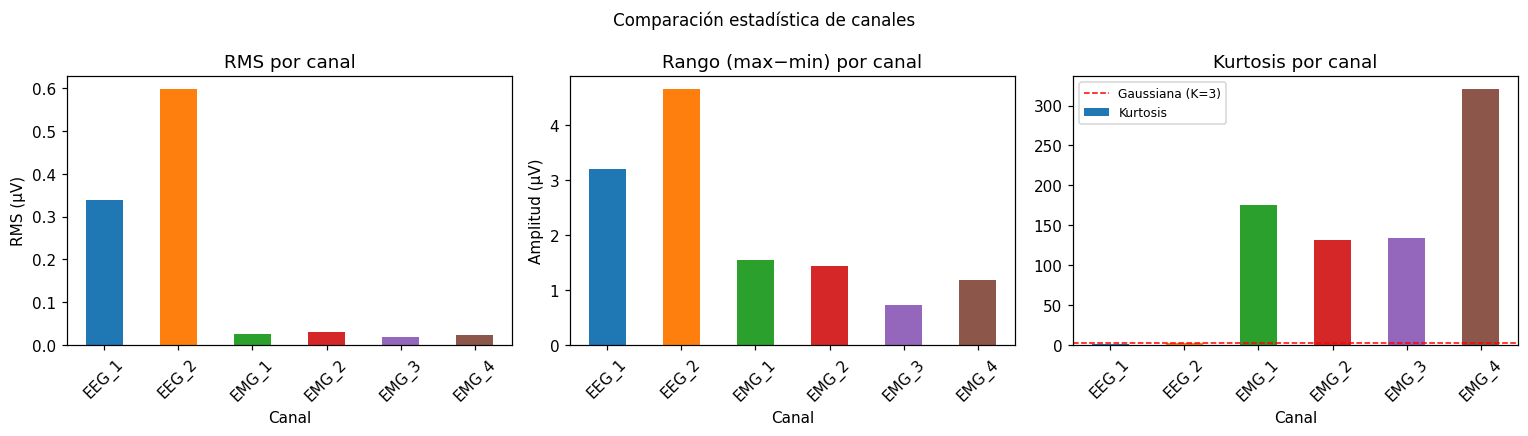

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = colors_eeg + colors_emg

stats_df['RMS'].plot(kind='bar', ax=axes[0], color=colors, title='RMS por canal')
axes[0].set_ylabel('RMS (µV)')
axes[0].tick_params(axis='x', rotation=45)

stats_df['Rango'].plot(kind='bar', ax=axes[1], color=colors, title='Rango (max−min) por canal')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].tick_params(axis='x', rotation=45)

stats_df['Kurtosis'].plot(kind='bar', ax=axes[2], color=colors, title='Kurtosis por canal')
axes[2].axhline(3, color='red', lw=1, ls='--', label='Gaussiana (K=3)')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Comparación estadística de canales', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Densidad espectral de potencia (PSD)

Ver en qué bandas concentra energía cada canal. Para EEG nos interesan las **bandas alfa (8–13 Hz) y beta (13–30 Hz)**. Alta kurtosis en EMG indica bursts musculares.

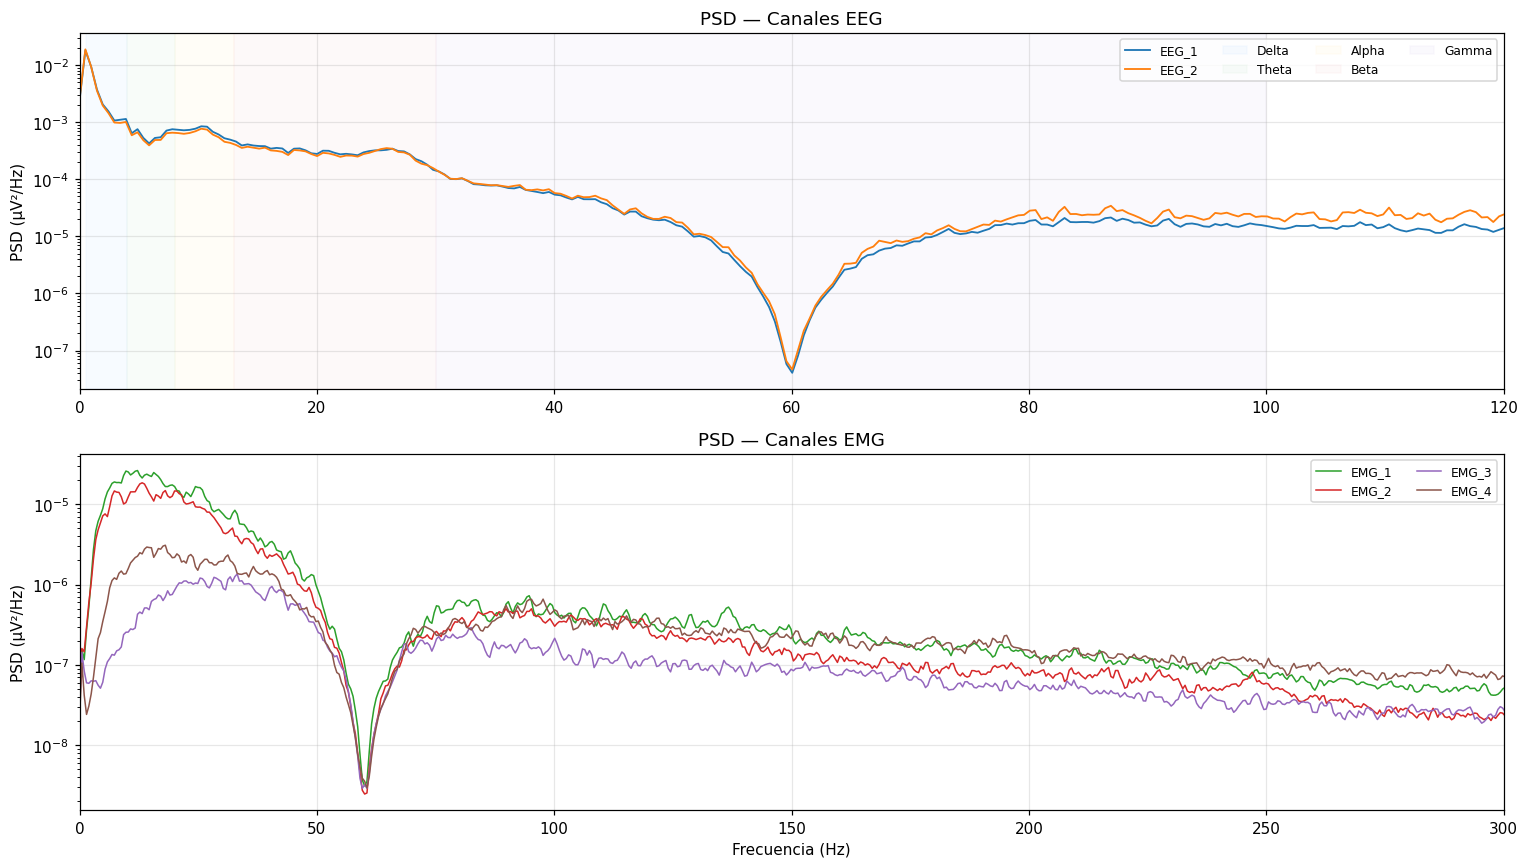

In [128]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# EEG PSD
for i, col in enumerate(eeg_cols):
    x = df[col].values
    freqs, psd = signal.welch(x, SRATE, nperseg=2048)
    axes[0].semilogy(freqs, psd, label=col, lw=1.2, color=colors_eeg[i])

bandas = [('Delta', 0.5, 4, '#cce5ff'), ('Theta', 4, 8, '#d4edda'),
          ('Alpha', 8, 13, '#fff3cd'), ('Beta', 13, 30, '#f8d7da'), ('Gamma', 30, 100, '#e2d9f3')]
for nombre, lo, hi, color in bandas:
    axes[0].axvspan(lo, hi, alpha=0.15, color=color, label=nombre)

axes[0].set_xlim(0, 120)
axes[0].set_title('PSD — Canales EEG')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].legend(fontsize=8, ncol=4)
axes[0].grid(True, alpha=0.3)

# EMG PSD
for j, col in enumerate(emg_cols):
    x = df[col].values
    freqs, psd = signal.welch(x, SRATE, nperseg=2048)
    axes[1].semilogy(freqs, psd, label=col, lw=1, color=colors_emg[j])

axes[1].set_xlim(0, 300)
axes[1].set_title('PSD — Canales EMG')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('PSD (µV²/Hz)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Zoom: primeros 10 segundos

Ver la morfología de la señal a nivel de muestra para detectar ruido de línea (50 Hz), artefactos de movimiento o saturaciones.

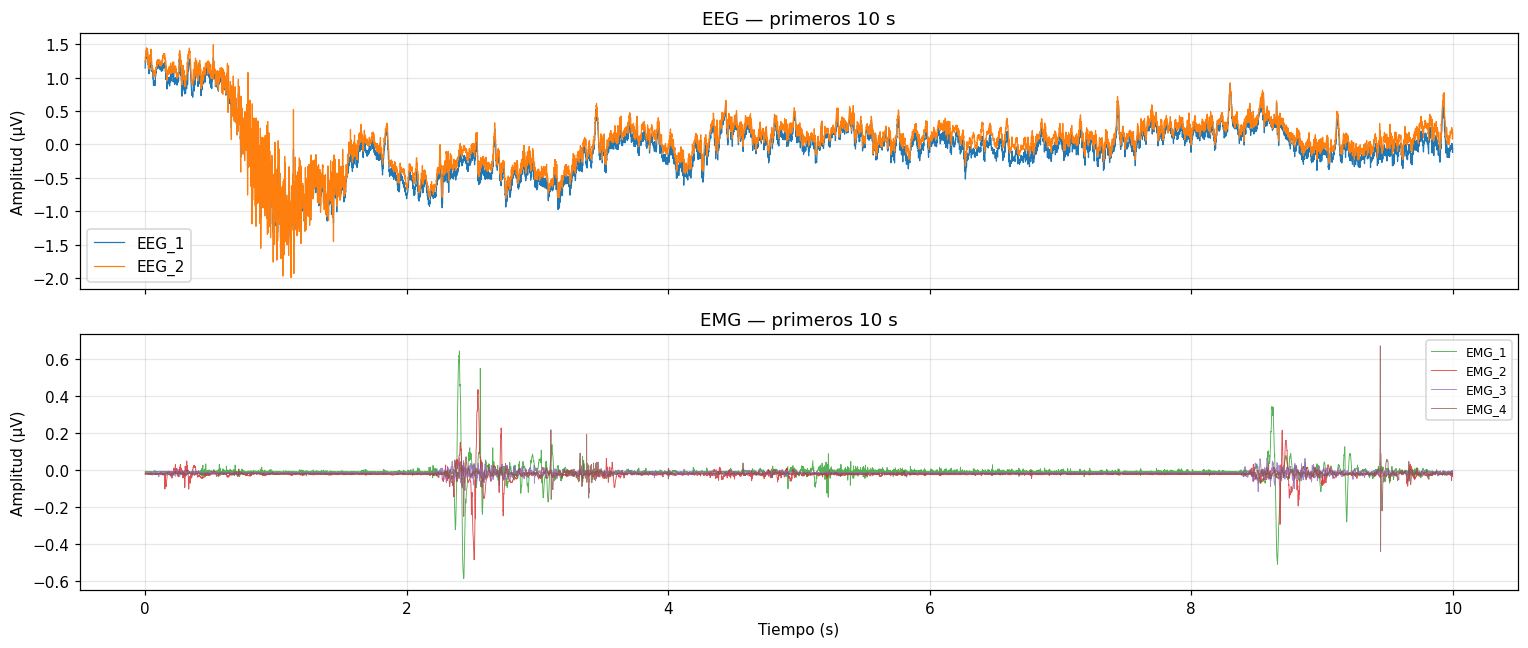

In [129]:
ZOOM_S = 10  # segundos a visualizar
n_zoom = int(ZOOM_S * SRATE)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for i, col in enumerate(eeg_cols):
    axes[0].plot(t[:n_zoom], df[col].values[:n_zoom], label=col, lw=0.8, color=colors_eeg[i])
axes[0].set_title(f'EEG — primeros {ZOOM_S} s')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for j, col in enumerate(emg_cols):
    axes[1].plot(t[:n_zoom], df[col].values[:n_zoom], label=col, lw=0.6, color=colors_emg[j], alpha=0.8)
axes[1].set_title(f'EMG — primeros {ZOOM_S} s')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ¿Cuál canal EMG usar como detector de bursts?

Evaluamos cuál de los 4 canales EMG tiene mayor varianza y kurtosis.

Un buen canal para burst detection tiene:
- **Alta kurtosis** → distribución con colas pesadas (eventos de alta amplitud bien definidos)
- **RMS alto relativo a la línea base** → buena relación señal/ruido
- **PSD con energía en 20–150 Hz** → banda típica del EMG muscular

In [130]:
emg_ranking = []
for col in emg_cols:
    x = df[col].values
    x_centered = x - np.mean(x)
    x_rect = np.abs(x_centered)
    
    # Energía en banda EMG (20–150 Hz)
    freqs, psd = signal.welch(x_centered, SRATE, nperseg=1024)
    mask_emg = (freqs >= 20) & (freqs <= 150)
    emg_band_power = np.trapezoid(psd[mask_emg], freqs[mask_emg])
    total_power = np.trapezoid(psd, freqs)
    emg_ratio = emg_band_power / total_power
    
    emg_ranking.append({
        'Canal'           : col,
        'RMS'             : np.sqrt(np.mean(x_centered**2)),
        'Kurtosis'        : kurtosis(x_rect),
        'Potencia_EMG_band': emg_band_power,
        'Ratio_EMG_band'  : emg_ratio,
        'Score'           : kurtosis(x_rect) * emg_ratio * 100,  # score compuesto
    })

ranking_df = pd.DataFrame(emg_ranking).set_index('Canal').sort_values('Score', ascending=False)
print('Ranking de canales EMG para detección de bursts:')
print('(mayor Score = mejor candidato)\n')
ranking_df.round(4)

Ranking de canales EMG para detección de bursts:
(mayor Score = mejor candidato)



,RMS,Kurtosis,Potencia_EMG_band,Ratio_EMG_band,Score
Canal,,,,,
EMG_4,0.0118,384.7079,0.0001,0.5240,20157.4404
EMG_3,0.0075,190.5134,0.0000,0.6918,13179.6701
EMG_1,0.0241,199.3777,0.0002,0.3674,7325.5324
EMG_2,0.0198,152.7639,0.0002,0.4058,6198.4186


Canal EMG recomendado para burst detection: EMG_4


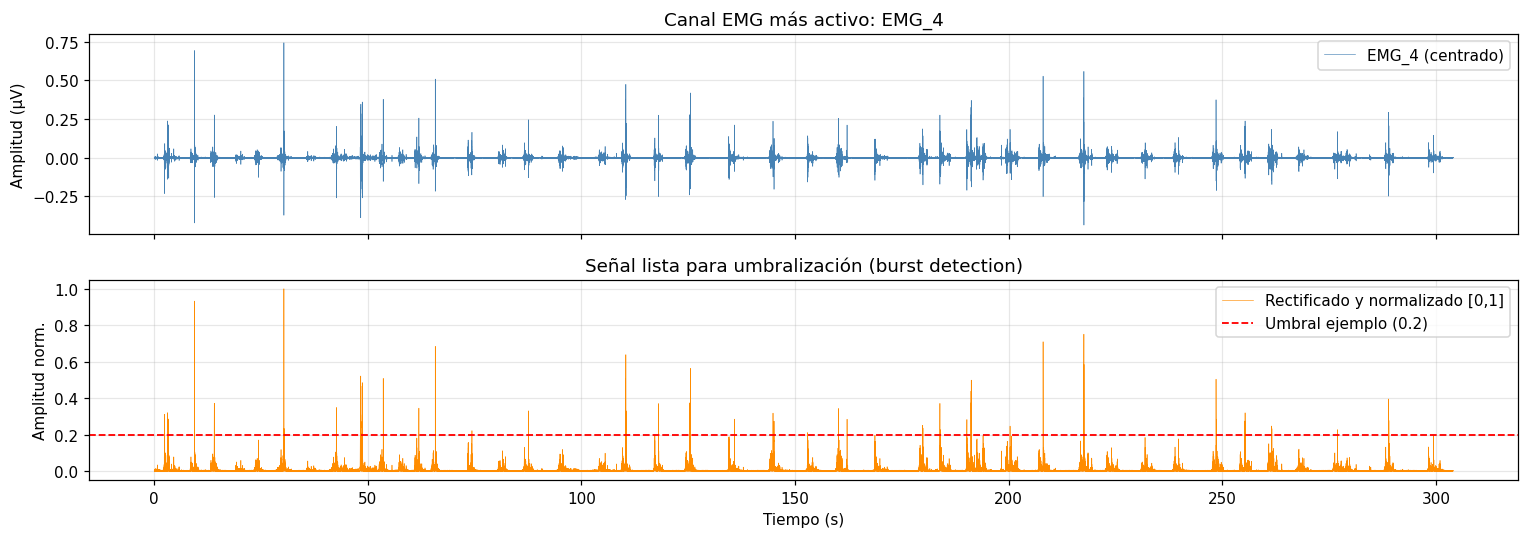

In [131]:
best_emg = ranking_df.index[0]
print(f'Canal EMG recomendado para burst detection: {best_emg}')

# Visualizar el mejor canal rectificado
x_best = df[best_emg].values
x_best = x_best - np.mean(x_best)
x_rect = np.abs(x_best)
# Normalizar entre 0 y 1 (como hace app_edu.py)
x_norm = (x_rect - x_rect.min()) / (x_rect.max() - x_rect.min())

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t, x_best, lw=0.4, color='steelblue', label=f'{best_emg} (centrado)')
axes[0].set_title(f'Canal EMG más activo: {best_emg}')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_norm, lw=0.4, color='darkorange', label='Rectificado y normalizado [0,1]')
axes[1].axhline(0.2, color='red', lw=1.2, ls='--', label='Umbral ejemplo (0.2)')
axes[1].set_title('Señal lista para umbralización (burst detection)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud norm.')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. EEG: verificar bandas de interés

Filtrar y visualizar la **banda Beta (13–30 Hz)** en EEG_1 y EEG_2. Esta es la banda clave para detectar **desincronización pre-movimiento** (ERDS).

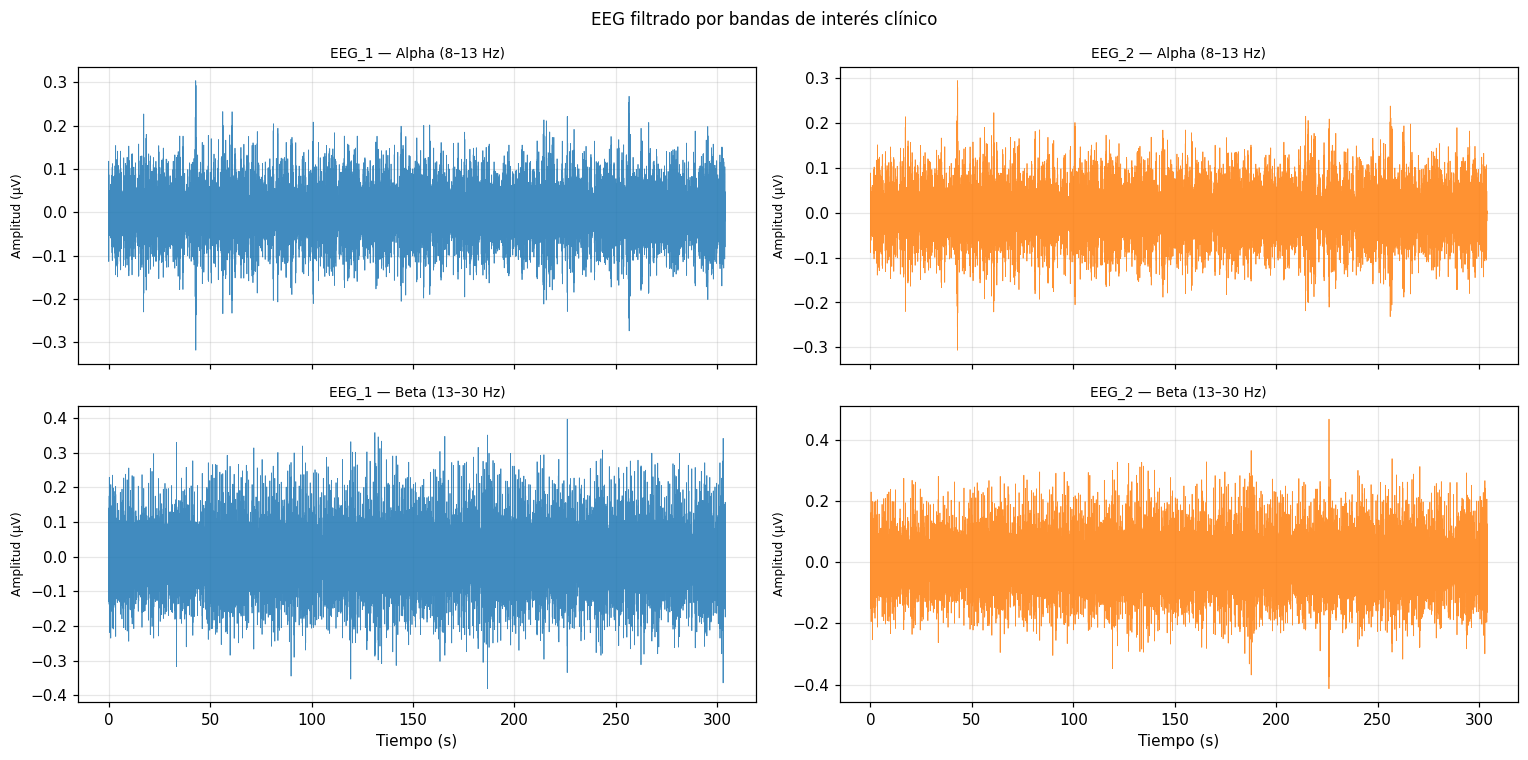

In [132]:
from scipy.signal import butter, sosfilt, sosfiltfilt

def bandpass(x, lo, hi, srate, order=4):
    nyq = srate / 2
    sos = butter(order, [lo/nyq, hi/nyq], btype='band', output='sos')
    return sosfiltfilt(sos, x)

bands = [
    ('Alpha (8–13 Hz)', 8, 13),
    ('Beta (13–30 Hz)', 13, 30),
]

# 2 EEG × 2 bandas
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

for row, (band_name, lo, hi) in enumerate(bands):
    for col_i, eeg_col in enumerate(eeg_cols):
        x = df[eeg_col].values
        x_filt = bandpass(x, lo, hi, SRATE)
        axes[row][col_i].plot(t, x_filt, lw=0.5, color=colors_eeg[col_i], alpha=0.85)
        axes[row][col_i].set_title(f'{eeg_col} — {band_name}', fontsize=9)
        axes[row][col_i].set_ylabel('Amplitud (µV)', fontsize=8)
        axes[row][col_i].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (s)')

plt.suptitle('EEG filtrado por bandas de interés clínico', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Espectrograma EEG — vista tiempo-frecuencia

Ver si hay modulación espectral a lo largo del tiempo (indicativo de actividad cognitiva/motora).

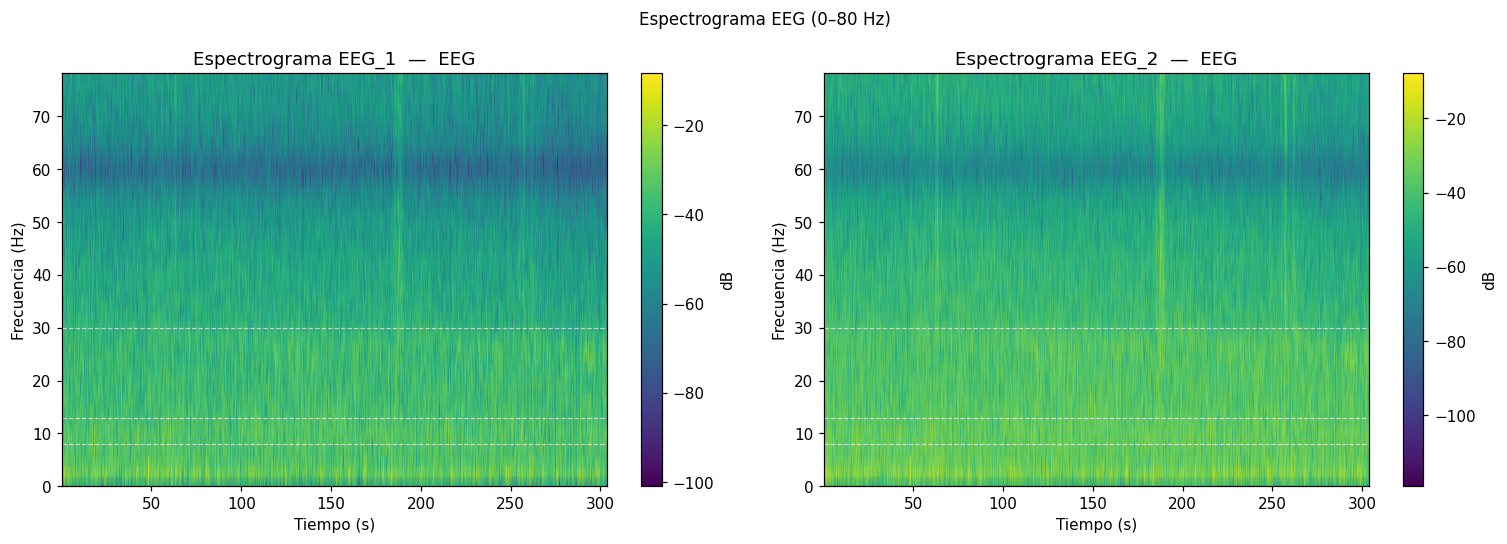

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(eeg_cols):
    x = df[col].values
    f, t_spec, Sxx = signal.spectrogram(x, SRATE, nperseg=512, noverlap=256)
    freq_mask = f <= 80
    im = axes[i].pcolormesh(t_spec, f[freq_mask], 10*np.log10(Sxx[freq_mask] + 1e-12),
                             shading='gouraud', cmap='viridis')
    axes[i].set_title(f'Espectrograma {col}  —  EEG')
    axes[i].set_xlabel('Tiempo (s)')
    axes[i].set_ylabel('Frecuencia (Hz)')
    for freq_line, label in [(8,'\u03b1'), (13,'\u03b2'), (30,'\u03b3')]:
        axes[i].axhline(freq_line, color='white', lw=0.8, ls='--', alpha=0.6)
        axes[i].text(t_spec[-1]*1.01, freq_line, label, color='white', fontsize=8, va='center')
    plt.colorbar(im, ax=axes[i], label='dB')

plt.suptitle('Espectrograma EEG (0–80 Hz)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Resumen y recomendaciones

Basado en el análisis anterior:

In [134]:
print('=' * 55)
print('RESUMEN DE EXPLORACIÓN')
print('=' * 55)
print(f'Duración total   : {df.Tiempo_s.iloc[-1]:.0f} s  ({df.Tiempo_s.iloc[-1]/60:.1f} min)')
print(f'Tasa de muestreo : {SRATE} Hz')
print(f'Muestras         : {len(df):,}')
print()
print('Canales EEG:')
for col in eeg_cols:
    print(f'  {col}: rango [{df[col].min():.3f}, {df[col].max():.3f}]')
print()
print('Canales EMG:')
for col in emg_cols:
    print(f'  {col}: rms={np.sqrt(np.mean(df[col].values**2)):.5f}  '
          f'rango [{df[col].min():.4f}, {df[col].max():.4f}]')
print()
print('Canal EMG recomendado para burst detection:')
print(f'  → {best_emg}  (mayor kurtosis y energía en banda 20–150 Hz)')
print()
print('Próximos pasos:')
print('  1. Aplicar filtros (highpass 1 Hz, lowpass 100 Hz, notch 50 Hz)')
print('  2. Comparar BacAV vs clustering espectral (Sección 10)')
print('  3. Usar bursts como marcadores → segmentar EEG')
print('  4. Calcular ERP y ERDS (desincronización beta pre-movimiento)')
print('=' * 55)

RESUMEN DE EXPLORACIÓN
Duración total   : 304 s  (5.1 min)
Tasa de muestreo : 1000 Hz
Muestras         : 304,011

Canales EEG:
  EEG_1: rango [-1.587, 1.618]
  EEG_2: rango [-1.988, 2.673]

Canales EMG:
  EMG_1: rms=0.02680  rango [-0.6875, 0.8581]
  EMG_2: rms=0.03103  rango [-0.8919, 0.5395]
  EMG_3: rms=0.01773  rango [-0.2200, 0.5102]
  EMG_4: rms=0.02437  rango [-0.4557, 0.7209]

Canal EMG recomendado para burst detection:
  → EMG_4  (mayor kurtosis y energía en banda 20–150 Hz)

Próximos pasos:
  1. Aplicar filtros (highpass 1 Hz, lowpass 100 Hz, notch 50 Hz)
  2. Comparar BacAV vs clustering espectral (Sección 10)
  3. Usar bursts como marcadores → segmentar EEG
  4. Calcular ERP y ERDS (desincronización beta pre-movimiento)


## 10. Comparación: detección de bursts EMG — BacAV vs Clustering Espectral

Comparamos dos enfoques para detectar el **onset de bursts musculares** en el canal EMG óptimo:

| Método | Principio |
|--------|-----------|
| **BacAV** (Vial et al., 2020) | Umbralización sobre señal rectificada y normalizada [0,1]; verifica amplitud media en ventana pre/post candidato |
| **K-Means espectral** | Extrae features por ventana corta (RMS + potencia 20–150 Hz) y agrupa en `burst` vs `reposo` |

La congruencia entre ambos valida que los eventos detectados corresponden a activaciones musculares reales.

### Celda 1 — Selección del canal EMG y detección de bursts con BacAV

Antes de comparar métodos, necesitamos elegir **con qué canal EMG trabajar** y **detectar los bursts**.

**Canal EMG:** usamos `best_emg`, el canal que obtuvo mayor score en la sección 6 (mayor kurtosis + mayor proporción de energía en 20–150 Hz). Ese canal es el que mejor representa la activación muscular.

**Algoritmo BacAV** (Vial et al., 2020):
El método opera en 4 pasos sobre la señal cruda:
1. **Centrar** la señal (restar la media) para eliminar offset DC
2. **Rectificar** (valor absoluto) — convierte picos positivos y negativos en una envolvente de amplitud
3. **Normalizar a [0,1]** — hace el umbral independiente de la ganancia del amplificador
4. **Umbralizar + verificar ventana pre/post** — un candidato a burst debe superar el umbral *y* tener baja amplitud antes y alta amplitud después, evitando falsos positivos por ruido puntual

El resultado es `bursts_bacav`: array con los índices de muestra del **onset** de cada burst.

In [135]:
# ── 1. Canal EMG seleccionado ─────────────────────────────────────────────────
EMG_CH  = best_emg
emg_raw = df[EMG_CH].values
t       = df['Tiempo_s'].values
print(f'Canal EMG seleccionado: {EMG_CH}')

# ── 2. Método BacAV ───────────────────────────────────────────────────────────
# Reproducción del algoritmo descrito en Vial et al. (2020):
# rectificar → normalizar [0,1] → umbralizar → verificar ventana pre/post

def detect_bursts_bacav(
    x, srate,
    threshold=0.10,
    time_before=0.1,
    time_after=0.10,
    amp_before=0.1,
    amp_after=0.05,
    burst_duration=0.3
):
    x_c    = x - np.mean(x)
    x_rect = np.abs(x_c)
    x_norm = (x_rect - x_rect.min()) / (x_rect.max() - x_rect.min())
    n_before = int(time_before * srate)
    n_after  = int(time_after  * srate)
    n_gap    = int(burst_duration * srate)
    bursts, last = [], -n_gap
    for idx in np.where(x_norm > threshold)[0]:
        if idx - last < n_gap:
            continue
        if idx < n_before or idx + n_after >= len(x_norm):
            continue
        if (np.mean(x_norm[idx - n_before:idx]) < amp_before and
                np.mean(x_norm[idx:idx + n_after]) > amp_after):
            bursts.append(idx)
            last = idx
    return np.array(bursts)

bursts_bacav = detect_bursts_bacav(emg_raw, SRATE)
print(f'BacAV   → {len(bursts_bacav):4d} bursts')

Canal EMG seleccionado: EMG_4
BacAV   →   30 bursts


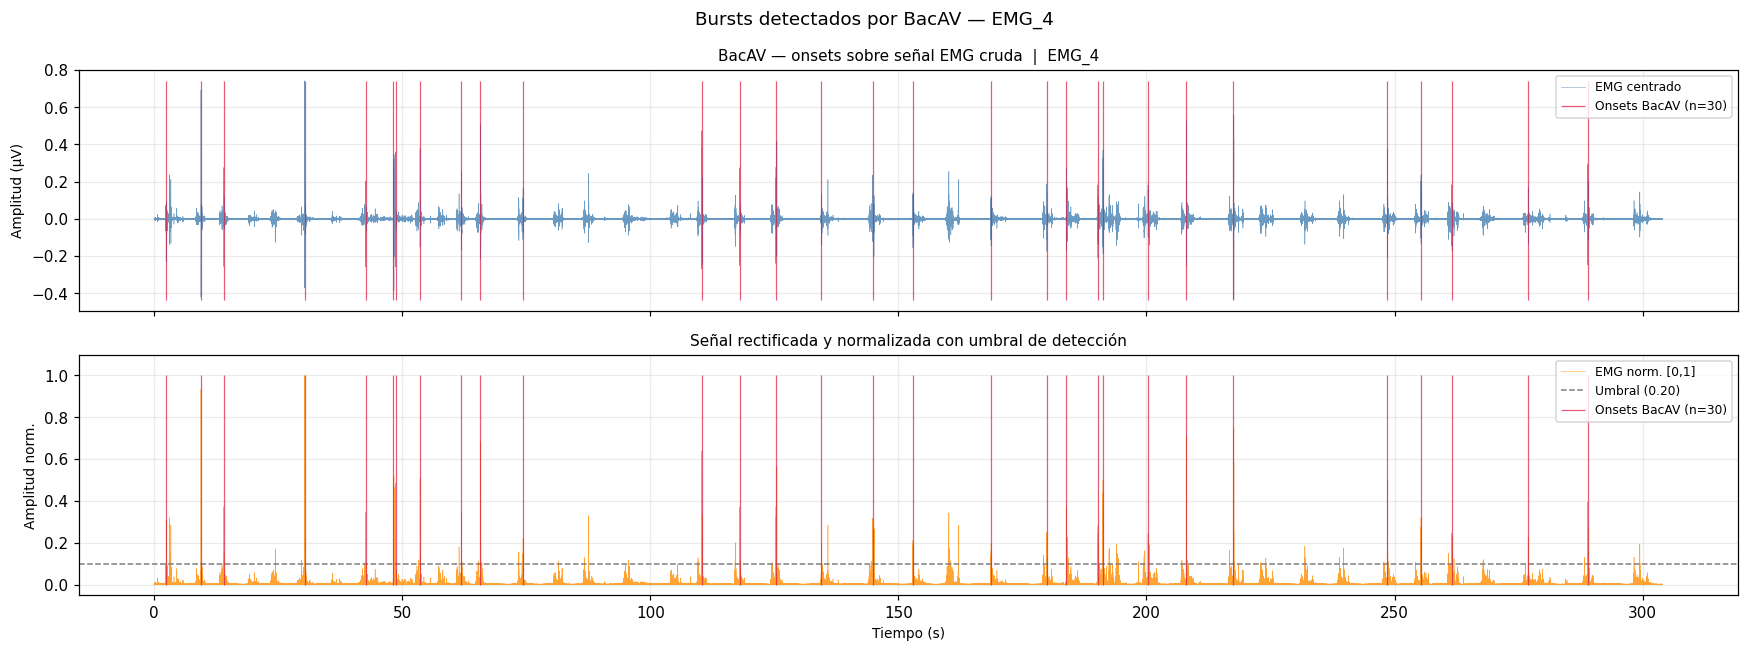

Total bursts BacAV : 30
Tasa media         : 5.9 bursts/min
Intervalo medio    : 9.88 s  ± 7.49 s


In [136]:
x_c_bv    = emg_raw - np.mean(emg_raw)
x_rect_bv = np.abs(x_c_bv)
x_norm_bv = (x_rect_bv - x_rect_bv.min()) / (x_rect_bv.max() - x_rect_bv.min())

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# ── Panel superior: señal cruda con marcadores ────────────────────────────────
axes[0].plot(t, x_c_bv, lw=0.35, color='steelblue', alpha=0.8, label='EMG centrado')
axes[0].vlines(t[bursts_bacav], x_c_bv.min(), x_c_bv.max(),
               color='crimson', lw=0.8, alpha=0.7, label=f'Onsets BacAV (n={len(bursts_bacav)})')
axes[0].set_title(f'BacAV — onsets sobre señal EMG cruda  |  {EMG_CH}', fontsize=10)
axes[0].set_ylabel('Amplitud (µV)', fontsize=9)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.25)

# ── Panel inferior: señal normalizada con umbral ──────────────────────────────
axes[1].plot(t, x_norm_bv, lw=0.35, color='darkorange', alpha=0.8, label='EMG norm. [0,1]')
axes[1].axhline(0.1, color='gray', lw=1, ls='--', label='Umbral (0.20)')
axes[1].vlines(t[bursts_bacav], 0, 1,
               color='crimson', lw=0.8, alpha=0.7, label=f'Onsets BacAV (n={len(bursts_bacav)})')
axes[1].set_title('Señal rectificada y normalizada con umbral de detección', fontsize=10)
axes[1].set_xlabel('Tiempo (s)', fontsize=9)
axes[1].set_ylabel('Amplitud norm.', fontsize=9)
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.25)

plt.suptitle(f'Bursts detectados por BacAV — {EMG_CH}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Total bursts BacAV : {len(bursts_bacav)}')
print(f'Tasa media         : {len(bursts_bacav) / t[-1] * 60:.1f} bursts/min')
print(f'Intervalo medio    : {np.mean(np.diff(t[bursts_bacav])):.2f} s  '
      f'± {np.std(np.diff(t[bursts_bacav])):.2f} s')

Bursts detectados: 30
Mostrando burst #0  (t = 2.37 s)


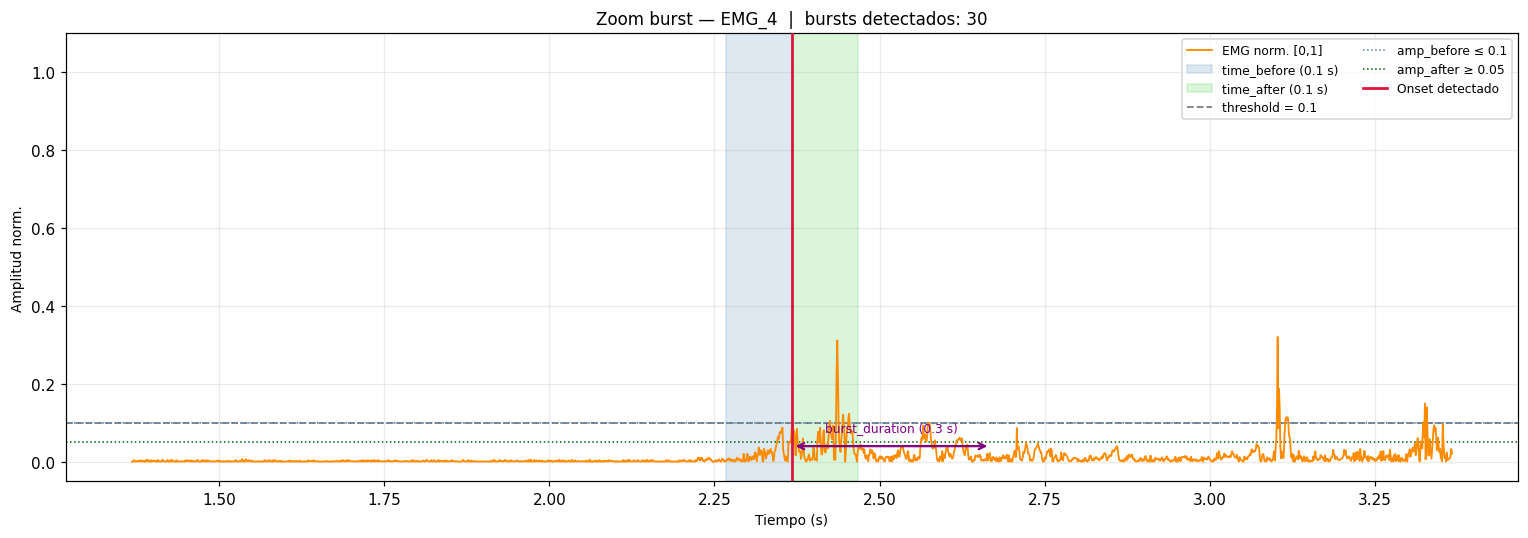

In [137]:
# ── Parámetros editables ──────────────────────────────────────────────────────

THRESHOLD      = 0.10   # nivel mínimo sobre señal norm. [0,1]
TIME_BEFORE    = 0.10   # ventana pre-onset (s)
TIME_AFTER     = 0.10   # ventana post-onset (s)
AMP_BEFORE     = 0.10   # media en ventana pre-onset debe ser < este valor
AMP_AFTER      = 0.05   # media en ventana post-onset debe ser > este valor
BURST_DURATION = 0.3   # gap mínimo entre bursts consecutivos (s)
MARGIN_S       = 1.0    # margen de zoom a cada lado del burst (s)

# Re-detectar con los parámetros actuales
bursts_bacav = detect_bursts_bacav(
    emg_raw, SRATE,
    threshold=THRESHOLD, time_before=TIME_BEFORE, time_after=TIME_AFTER,
    amp_before=AMP_BEFORE, amp_after=AMP_AFTER, burst_duration=BURST_DURATION,
)
print(f'Bursts detectados: {len(bursts_bacav)}')

# Elegir el burst a visualizar (índice 0 = primero; cambia si quieres otro)
if len(bursts_bacav) > 0:
    center_idx = bursts_bacav[0]
    print(f'Mostrando burst #0  (t = {t[center_idx]:.2f} s)')
else:
    center_idx = int(np.argmax(x_norm_bv))
    print(f'⚠ Sin bursts detectados — mostrando pico máximo (t = {t[center_idx]:.2f} s)')

# ── Ventana de zoom ───────────────────────────────────────────────────────────
n_margin  = int(MARGIN_S * SRATE)
s_zoom    = max(0, center_idx - n_margin)
e_zoom    = min(len(emg_raw), center_idx + n_margin)
t_zoom    = t[s_zoom:e_zoom]
sig_zoom  = x_norm_bv[s_zoom:e_zoom]
local_idx = center_idx - s_zoom

n_bef = int(TIME_BEFORE * SRATE)
n_aft = int(TIME_AFTER  * SRATE)
t_onset      = t_zoom[local_idx]
t_bef_start  = t_zoom[max(0, local_idx - n_bef)]
t_aft_end    = t_zoom[min(len(t_zoom) - 1, local_idx + n_aft)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t_zoom, sig_zoom, lw=1.2, color='darkorange', zorder=3, label='EMG norm. [0,1]')

# Zonas pre/post onset
ax.axvspan(t_bef_start, t_onset,   alpha=0.18, color='steelblue',
           label=f'time_before ({TIME_BEFORE} s)')
ax.axvspan(t_onset,     t_aft_end, alpha=0.18, color='limegreen',
           label=f'time_after ({TIME_AFTER} s)')

# Líneas de parámetros
ax.axhline(THRESHOLD,  color='gray',       lw=1.2, ls='--', label=f'threshold = {THRESHOLD}')
ax.axhline(AMP_BEFORE, color='steelblue',  lw=1.0, ls=':',  label=f'amp_before ≤ {AMP_BEFORE}')
ax.axhline(AMP_AFTER,  color='darkgreen',  lw=1.0, ls=':',  label=f'amp_after ≥ {AMP_AFTER}')

# Onset
ax.axvline(t_onset, color='crimson', lw=1.8, zorder=4, label='Onset detectado')

# Flecha burst_duration
y_arrow = 0.04
ax.annotate('', xy=(t_onset + BURST_DURATION, y_arrow), xytext=(t_onset, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(t_onset + BURST_DURATION / 2, y_arrow + 0.04,
        f'burst_duration ({BURST_DURATION} s)', ha='center', fontsize=8, color='purple')

ax.set_title(f'Zoom burst — {EMG_CH}  |  bursts detectados: {len(bursts_bacav)}', fontsize=11)
ax.set_xlabel('Tiempo (s)', fontsize=9)
ax.set_ylabel('Amplitud norm.', fontsize=9)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Ajuste de parámetros BacAV — zoom en un burst

La celda siguiente muestra un zoom de **±1 segundo alrededor del primer burst** con todos los parámetros del algoritmo dibujados directamente sobre la señal.

| Parámetro | Qué controla |
|---|---|
| `THRESHOLD` | Nivel mínimo que debe superar la señal normalizada para ser candidato. Bajar este valor → más candidatos. |
| `TIME_BEFORE` | Ventana (s) que se mira *antes* del candidato para verificar que estaba en reposo. |
| `TIME_AFTER` | Ventana (s) que se mira *después* del candidato para verificar que hay actividad sostenida. |
| `AMP_BEFORE` | La media en la ventana pre-onset debe ser **menor** que este valor (confirma reposo previo). |
| `AMP_AFTER` | La media en la ventana post-onset debe ser **mayor** que este valor (confirma activación real). |
| `BURST_DURATION` | Gap mínimo entre dos bursts consecutivos. Dos detecciones más cercanas que esto se fusionan en una. |

**Cómo usar:** edita los valores en la celda de abajo y re-ejecútala. El título del plot y el print muestran cuántos bursts quedan con esos parámetros. Una vez satisfecho, copia los valores a la función `detect_bursts_bacav` de la Celda 1.

### Celda 3 — Visualización interna del K-Means (3 paneles)

Esta figura muestra **cómo quedaron los clusters del K-Means**, no los bursts en sí. Tiene 3 paneles:

**Panel A — Espacio de features (scatter)**
Cada punto es una ventana de 50 ms. El eje X es su RMS, el eje Y es su potencia en 20–150 Hz. El K-Means separó estas ventanas en 2 grupos (verde = burst, rojo = reposo). Si los clusters están bien separados, significa que la distinción burst/reposo es clara en los datos.

**Panel B — Boxplot de RMS por cluster**
Confirma que el cluster "burst" tiene RMS significativamente mayor que el de "reposo". Si las cajas se solapan mucho, la separación es ambigua.

**Panel C — Línea temporal completa**
Muestra toda la grabación con las **zonas clasificadas como burst sombreadas en verde**. Aquí se reconstruye la etiqueta de cada muestra a partir de la etiqueta de su ventana más cercana (paso = 10 ms), lo que preserva la resolución temporal real del K-Means. El título indica cuántos segundos totales fueron clasificados como burst vs. reposo.

In [138]:
from sklearn.cluster      import KMeans
from sklearn.preprocessing import StandardScaler

# ── 3. Método K-Means espectral ───────────────────────────────────────────────
WIN_S = 0.050
HOP_S = 0.010
n_win = int(WIN_S * SRATE)
n_hop = int(HOP_S * SRATE)

x_c    = emg_raw - np.mean(emg_raw)
x_rect = np.abs(x_c)

feat_list, time_list = [], []
for start in range(0, len(x_c) - n_win, n_hop):
    seg      = x_c[start:start + n_win]
    rms      = float(np.sqrt(np.mean(np.abs(seg)**2)))
    fw, pw   = signal.welch(seg, SRATE, nperseg=n_win)
    m        = (fw >= 20) & (fw <= 150)
    band_pow = float(np.trapezoid(pw[m], fw[m])) if m.sum() > 1 else 0.0
    feat_list.append([rms, band_pow])
    time_list.append((start + n_win // 2) / SRATE)

feat_arr = np.array(feat_list)
time_arr = np.array(time_list)

feat_sc       = StandardScaler().fit_transform(feat_arr)
labels_km     = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(feat_sc)
burst_cluster = int(np.argmax([feat_arr[labels_km == i, 0].mean() for i in range(2)]))
burst_mask_km = labels_km == burst_cluster

transitions   = np.where(np.diff(burst_mask_km.astype(int)) == 1)[0]
bursts_kmeans = (time_arr[transitions] * SRATE).astype(int)
print(f'K-Means → {len(bursts_kmeans):4d} bursts')
print(f'Diferencia: {abs(len(bursts_bacav) - len(bursts_kmeans))} bursts')

K-Means →   43 bursts
Diferencia: 13 bursts


### 10.1 Visualización de grupos K-Means (espacio de features + línea temporal)

**Ventaneo deslizante con solapamiento**

El RMS y la potencia de banda se calculan en **cada ventana**, avanzando de a un hop:

```
Ventana 1:  |←── 50 ms ──→|
Ventana 2:       |←── 50 ms ──→|
                 ↑
               10 ms de avance
```

Con ventana de 50 ms y paso de 10 ms, cada ventana comparte **40 ms (80%)** con la anterior. Esto es intencional: si el paso fuera igual a la ventana (sin solapamiento), los features cambiarían de golpe cada 50 ms y la clasificación K-Means sería mucho más ruidosa. El solapamiento suaviza la transición entre ventanas y da mejor resolución temporal.

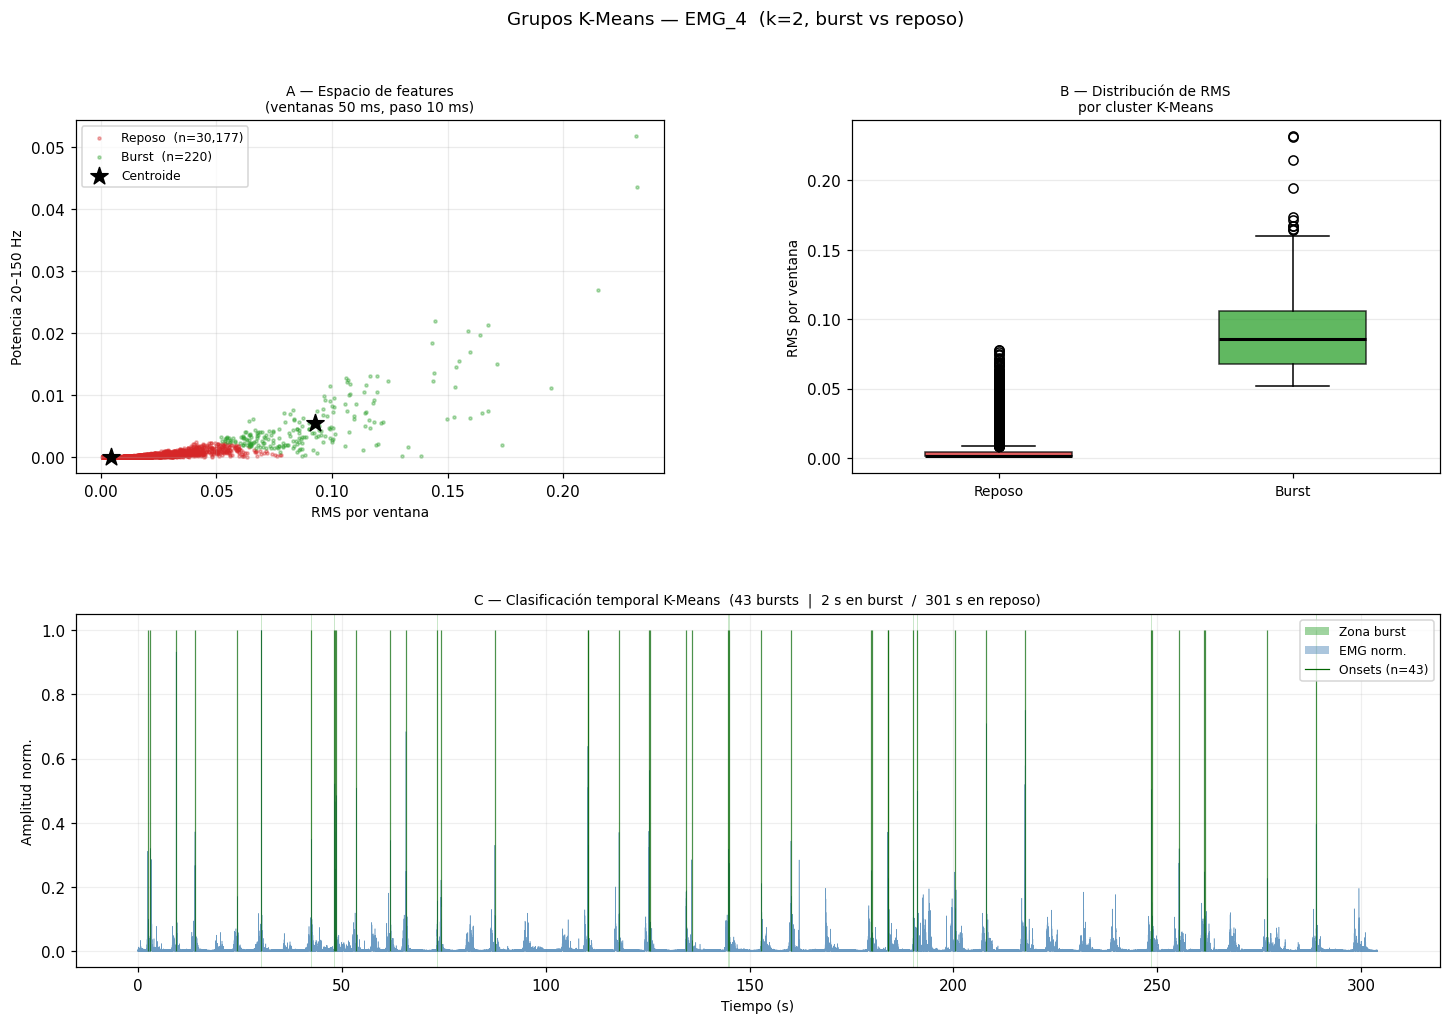

Ventanas totales : 30,397
  Burst          : 220  (0.7 %)
  Reposo         : 30,177  (99.3 %)
  Episodios burst: 45


In [139]:
# ── Visualización de grupos K-Means ──────────────────────────────────────────
PALETTE = {burst_cluster: '#2ca02c', 1 - burst_cluster: '#d62728'}
LABELS  = {burst_cluster: 'Burst', 1 - burst_cluster: 'Reposo'}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)

# ── Panel A: espacio de features ─────────────────────────────────────────────
ax_feat = fig.add_subplot(gs[0, 0])
for cl in [0, 1]:
    mask = labels_km == cl
    ax_feat.scatter(feat_arr[mask, 0], feat_arr[mask, 1],
                    s=4, alpha=0.35, color=PALETTE[cl],
                    label=f'{LABELS[cl]}  (n={mask.sum():,})', rasterized=True)
centers_orig = np.array([feat_arr[labels_km == cl].mean(axis=0) for cl in range(2)])
ax_feat.scatter(centers_orig[:, 0], centers_orig[:, 1],
                s=140, marker='*', color='black', zorder=5, label='Centroide')
ax_feat.set_xlabel('RMS por ventana', fontsize=9)
ax_feat.set_ylabel('Potencia 20–150 Hz', fontsize=9)
ax_feat.set_title('A — Espacio de features\n(ventanas 50 ms, paso 10 ms)', fontsize=9)
ax_feat.legend(fontsize=8)
ax_feat.grid(True, alpha=0.25)

# ── Panel B: boxplot de RMS ───────────────────────────────────────────────────
ax_box = fig.add_subplot(gs[0, 1])
data_box = [feat_arr[labels_km == cl, 0] for cl in range(2)]
bp = ax_box.boxplot(data_box, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
for patch, cl in zip(bp['boxes'], range(2)):
    patch.set_facecolor(PALETTE[cl])
    patch.set_alpha(0.75)
ax_box.set_xticklabels([LABELS[cl] for cl in range(2)], fontsize=9)
ax_box.set_ylabel('RMS por ventana', fontsize=9)
ax_box.set_title('B — Distribución de RMS\npor cluster K-Means', fontsize=9)
ax_box.grid(True, alpha=0.25, axis='y')

# ── Panel C: línea temporal completa ─────────────────────────────────────────
ax_time = fig.add_subplot(gs[1, :])

n_total    = len(emg_raw)
n_hop_half = n_hop // 2
color_line = np.full(n_total, 1 - burst_cluster, dtype=int)
for i, ts in enumerate(time_arr):
    idx = int(ts * SRATE)
    s = max(0, idx - n_hop_half)
    e = min(n_total, idx + n_hop_half)
    color_line[s:e] = labels_km[i]

in_burst = color_line == burst_cluster
transitions_c = np.diff(in_burst.astype(int))
starts = np.where(transitions_c ==  1)[0]
ends   = np.where(transitions_c == -1)[0]
if in_burst[0]:
    starts = np.concatenate([[0], starts])
if in_burst[-1]:
    ends = np.concatenate([ends, [n_total - 1]])

x_norm2 = np.abs(emg_raw - emg_raw.mean())
x_norm2 = (x_norm2 - x_norm2.min()) / (x_norm2.max() - x_norm2.min())

# Zonas burst sombreadas
for s, e in zip(starts, ends):
    ax_time.axvspan(t[s], t[e], alpha=0.25, color='#2ca02c', lw=0)

# Señal
ax_time.plot(t, x_norm2, lw=0.35, color='steelblue', alpha=0.8)

# Onsets como líneas verticales (visibles a cualquier escala)
ax_time.vlines(t[bursts_kmeans], 0, 1,
               color='darkgreen', lw=0.8, alpha=0.7,
               label=f'Onsets K-Means (n={len(bursts_kmeans)})')

ax_time.set_xlabel('Tiempo (s)', fontsize=9)
ax_time.set_ylabel('Amplitud norm.', fontsize=9)
burst_s  = int(in_burst.sum() / SRATE)
reposo_s = int((~in_burst).sum() / SRATE)
ax_time.set_title(
    f'C — Clasificación temporal K-Means  '
    f'({len(bursts_kmeans)} bursts  |  {burst_s} s en burst  /  {reposo_s} s en reposo)',
    fontsize=9)
ax_time.grid(True, alpha=0.20)

from matplotlib.patches import Patch
ax_time.legend(handles=[
    Patch(facecolor='#2ca02c', alpha=0.45, label='Zona burst'),
    Patch(facecolor='steelblue', alpha=0.45, label='EMG norm.'),
    plt.Line2D([0], [0], color='darkgreen', lw=0.8, label=f'Onsets (n={len(bursts_kmeans)})'),
], fontsize=8, loc='upper right')

plt.suptitle(f'Grupos K-Means — {EMG_CH}  (k=2, burst vs reposo)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Ventanas totales : {len(labels_km):,}')
print(f'  Burst          : {(labels_km == burst_cluster).sum():,}  '
      f'({(labels_km == burst_cluster).mean()*100:.1f} %)')
print(f'  Reposo         : {(labels_km != burst_cluster).sum():,}  '
      f'({(labels_km != burst_cluster).mean()*100:.1f} %)')
print(f'  Episodios burst: {len(starts):,}')


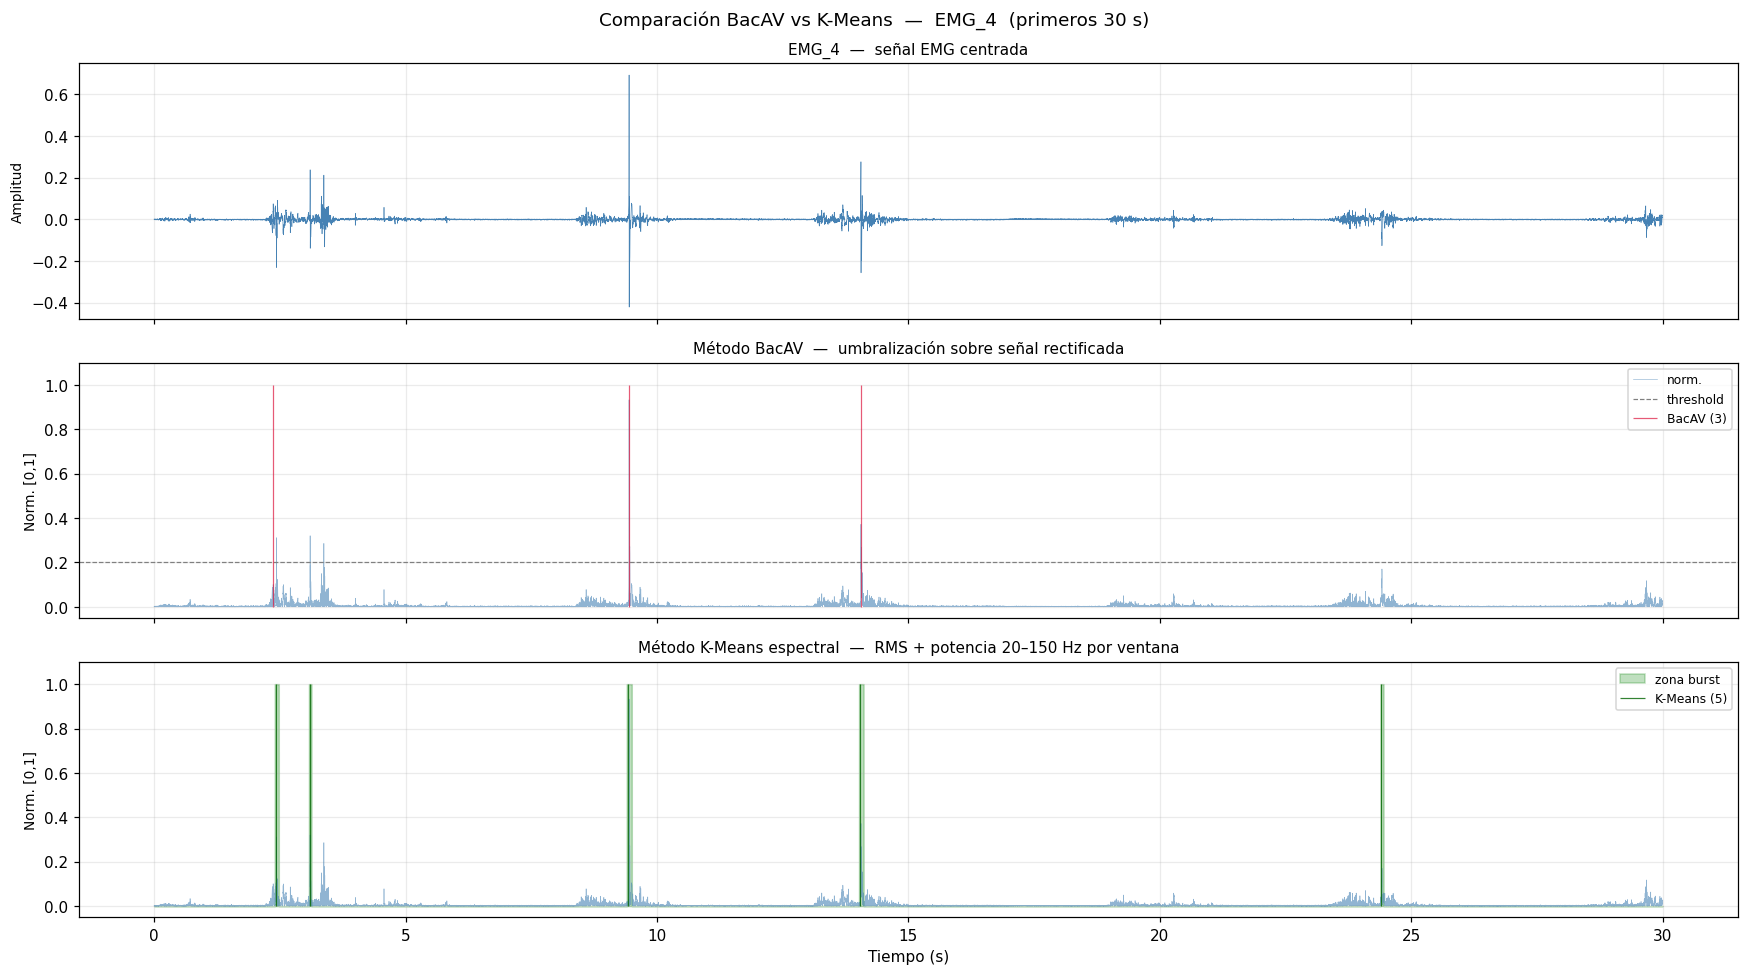

In [140]:
# ── 4. Visualización comparativa (primeros 30 s) ──────────────────────────────
SHOW_S   = 30
n_show   = int(SHOW_S * SRATE)

x_c_full    = emg_raw - np.mean(emg_raw)
x_rect_full = np.abs(x_c_full)
x_norm_full = (x_rect_full - x_rect_full.min()) / (x_rect_full.max() - x_rect_full.min())

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(t[:n_show], x_c_full[:n_show], lw=0.4, color='steelblue')
axes[0].set_title(f'{EMG_CH}  —  señal EMG centrada', fontsize=10)
axes[0].set_ylabel('Amplitud', fontsize=9)
axes[0].grid(True, alpha=0.25)

bv_show = bursts_bacav[bursts_bacav < n_show]
axes[1].plot(t[:n_show], x_norm_full[:n_show], lw=0.4, color='steelblue', alpha=0.6, label='norm.')
axes[1].axhline(0.20, color='gray', lw=0.8, ls='--', label='threshold')
axes[1].vlines(t[bv_show], 0, 1, color='crimson', lw=0.8, alpha=0.7, label=f'BacAV ({len(bv_show)})')
axes[1].set_title('Método BacAV  —  umbralización sobre señal rectificada', fontsize=10)
axes[1].set_ylabel('Norm. [0,1]', fontsize=9)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.25)
axes[1].set_ylim(-0.05, 1.1)

burst_signal = np.zeros(n_show)
for i, ts in enumerate(time_arr):
    idx = int(ts * SRATE)
    if idx >= n_show:
        break
    s = max(0, idx - n_win // 2)
    e = min(n_show, idx + n_win // 2)
    if burst_mask_km[i]:
        burst_signal[s:e] = 1

km_show = bursts_kmeans[bursts_kmeans < n_show]
axes[2].fill_between(t[:n_show], 0, burst_signal, alpha=0.25, color='green', label='zona burst')
axes[2].plot(t[:n_show], x_norm_full[:n_show], lw=0.4, color='steelblue', alpha=0.6)
axes[2].vlines(t[km_show], 0, 1, color='darkgreen', lw=0.8, alpha=0.8, label=f'K-Means ({len(km_show)})')
axes[2].set_title('Método K-Means espectral  —  RMS + potencia 20–150 Hz por ventana', fontsize=10)
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Norm. [0,1]', fontsize=9)
axes[2].legend(fontsize=8, loc='upper right')
axes[2].grid(True, alpha=0.25)
axes[2].set_ylim(-0.05, 1.1)

plt.suptitle(f'Comparación BacAV vs K-Means  —  {EMG_CH}  (primeros {SHOW_S} s)', fontsize=12)
plt.tight_layout()
plt.show()

### Celda 4 — Comparación visual BacAV vs K-Means (primeros 30 s)

Esta figura compara directamente los dos métodos sobre la **misma ventana temporal de 30 segundos**, con 3 paneles apilados que comparten el eje X:

**Panel 1 — Señal EMG cruda (centrada)**
La señal tal como viene del amplificador, solo con la media restada. Sirve como referencia visual para ver cuándo hay actividad muscular real.

**Panel 2 — Método BacAV**
- La señal rectificada y normalizada [0,1] (la misma que procesa el algoritmo)
- La línea discontinua gris es el umbral (0.20)
- Cada **línea vertical roja** es un onset de burst detectado por BacAV
- La leyenda muestra cuántos bursts caen dentro de estos 30 s

**Panel 3 — Método K-Means**
- El **área verde sombreada** son las zonas que K-Means clasificó como "burst" en estos 30 s
- Cada **línea vertical verde oscuro** es el onset de un episodio burst según K-Means
- La leyenda muestra cuántos onsets caen dentro de estos 30 s

**Qué buscar:** que las líneas rojas (BacAV) y verdes (K-Means) aparezcan en los mismos momentos, y que ambas coincidan con los picos visibles en el panel 1. Si hay buena concordancia, ambos métodos están detectando las mismas activaciones musculares.

Tolerancia: ±200 ms
Bursts BacAV  con match K-Means :   29/30  (96.7%)
Bursts K-Means con match BacAV  :   35/43  (81.4%)


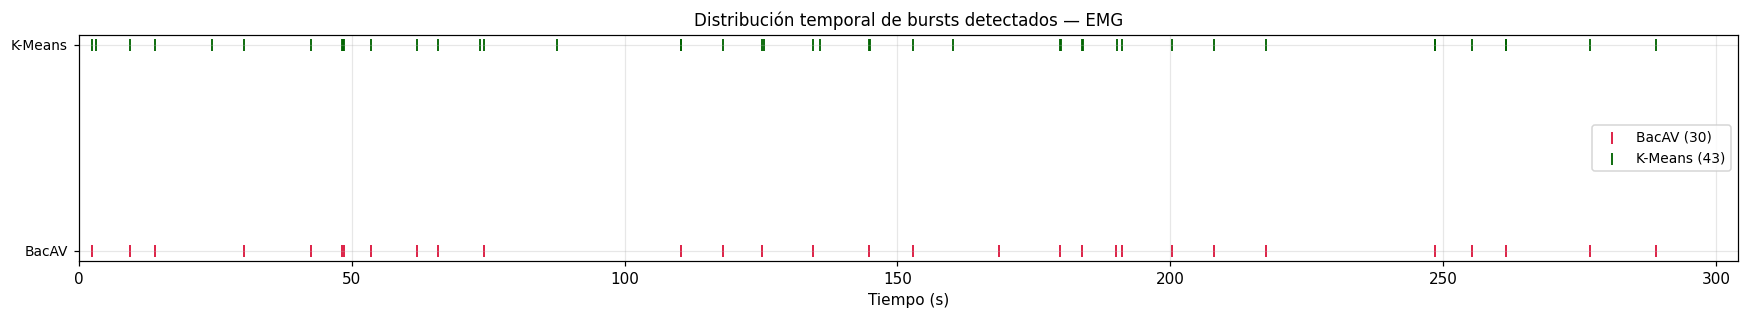

In [141]:
# ── 5. Concordancia cuantitativa (±200 ms) ────────────────────────────────────
TOL_S = 0.200

matched_bv = sum(
    1 for b in bursts_bacav if np.any(np.abs(bursts_kmeans - b) / SRATE <= TOL_S)
)
matched_km = sum(
    1 for b in bursts_kmeans if np.any(np.abs(bursts_bacav - b) / SRATE <= TOL_S)
)

prec_bv = matched_bv / len(bursts_bacav)  * 100 if len(bursts_bacav)  else 0
recall  = matched_km / len(bursts_kmeans) * 100 if len(bursts_kmeans) else 0

print(f'Tolerancia: ±{int(TOL_S*1000)} ms')
print(f'Bursts BacAV  con match K-Means : {matched_bv:4d}/{len(bursts_bacav)}  ({prec_bv:.1f}%)')
print(f'Bursts K-Means con match BacAV  : {matched_km:4d}/{len(bursts_kmeans)}  ({recall:.1f}%)')

fig, ax = plt.subplots(figsize=(16, 3))
ax.scatter(t[bursts_bacav],  np.ones(len(bursts_bacav)),   marker='|', s=60,
           color='crimson',   label=f'BacAV ({len(bursts_bacav)})',   lw=1.2)
ax.scatter(t[bursts_kmeans], np.ones(len(bursts_kmeans))*1.5, marker='|', s=60,
           color='darkgreen', label=f'K-Means ({len(bursts_kmeans)})', lw=1.2)
ax.set_yticks([1, 1.5])
ax.set_yticklabels(['BacAV', 'K-Means'], fontsize=9)
ax.set_xlabel('Tiempo (s)')
ax.set_xlim(0, t[-1])
ax.set_title('Distribución temporal de bursts detectados — EMG', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Celda 5 — Concordancia cuantitativa entre métodos

La concordancia visual del panel anterior no es suficiente: necesitamos un número que diga **qué tan de acuerdo están BacAV y K-Means**.

**Criterio de match (±200 ms):** se considera que dos bursts coinciden si sus onsets están a menos de 200 ms de distancia. Esta tolerancia tiene sentido porque ambos métodos pueden detectar el onset en momentos ligeramente distintos del mismo evento muscular.

**Métricas calculadas:**
- `% BacAV con match`: de todos los bursts de BacAV, ¿qué fracción tiene un burst K-Means cercano? → mide si BacAV está detectando eventos reales (no ruido)
- `% K-Means con match`: de todos los bursts de K-Means, ¿qué fracción tiene un burst BacAV cercano? → mide si K-Means no está generando falsos positivos

**Figura de barras temporales:** muestra todos los bursts detectados (no solo 30 s) como barras verticales a lo largo del tiempo. BacAV en rojo (fila inferior), K-Means en verde (fila superior). Si las barras se alinean verticalmente, los métodos concuerdan. Si hay barras aisladas sin contraparte, ese método está detectando algo que el otro no ve.

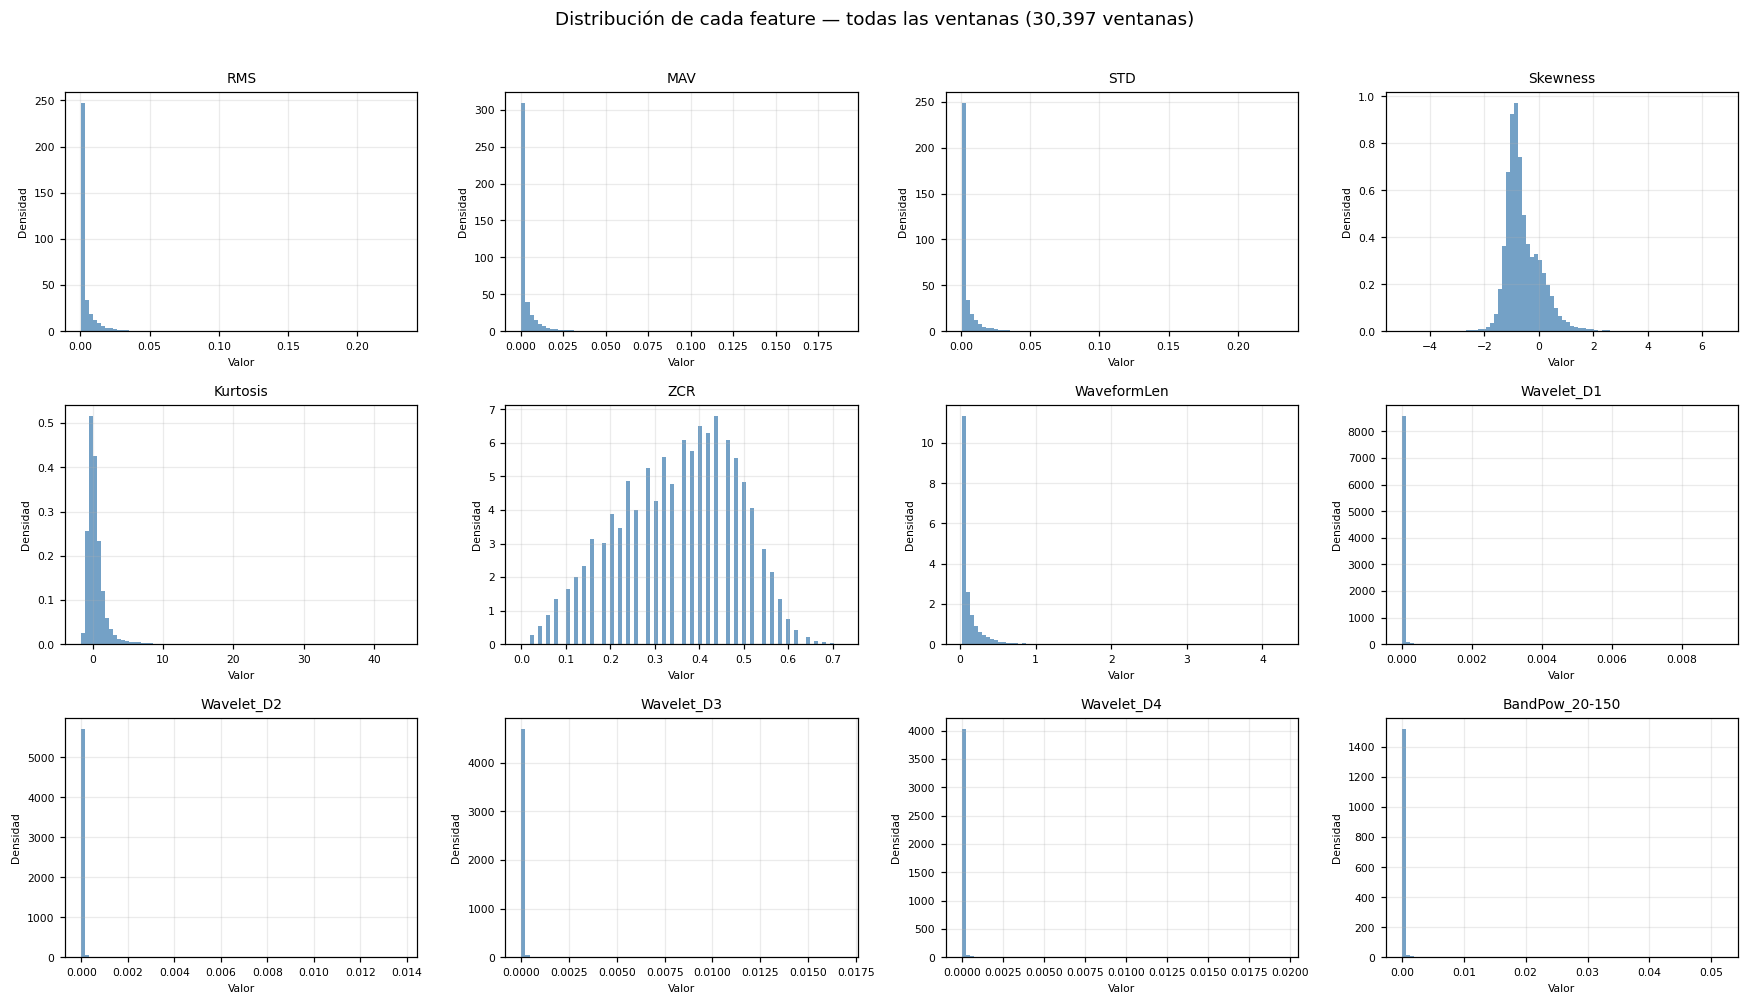

In [142]:
# ── Histogramas de distribución global de cada feature ────────────────────────
n_feat = len(FEATURE_NAMES)
ncols  = 4
nrows  = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.0))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(FEATURE_NAMES, axes)):
    ax.hist(feat11_arr[:, i], bins=80, color='steelblue', alpha=0.75, density=True)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Valor', fontsize=7)
    ax.set_ylabel('Densidad', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)

for ax in axes[n_feat:]:
    ax.set_visible(False)

plt.suptitle(f'Distribución de cada feature — todas las ventanas ({len(feat11_arr):,} ventanas)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [143]:
# ── HDBSCAN sobre todas las ventanas (12 features) ───────────────────────────
feat11_sc      = StandardScaler().fit_transform(feat11_arr)
hdb_all        = HDBSCAN(min_cluster_size=50, min_samples=10)
labels_hdb_all = hdb_all.fit_predict(feat11_sc)

n_cls_all   = len(set(labels_hdb_all)) - (1 if -1 in labels_hdb_all else 0)
n_noise_all = (labels_hdb_all == -1).sum()

print(f'HDBSCAN — {len(feat11_arr):,} ventanas · 12 features')
print(f'Clusters encontrados : {n_cls_all}')
print(f'Puntos de ruido      : {n_noise_all:,}  ({n_noise_all / len(labels_hdb_all) * 100:.1f} %)')
print()
for cl in sorted(set(labels_hdb_all)):
    tag  = 'Ruido' if cl == -1 else f'Cluster {cl}'
    mask = labels_hdb_all == cl
    print(f'  {tag:12s}: {mask.sum():>6,} ventanas'
          f'  RMS_medio={feat11_arr[mask, 0].mean():.5f}'
          f'  Kurt_medio={feat11_arr[mask, 4].mean():.1f}')

HDBSCAN — 30,397 ventanas · 12 features
Clusters encontrados : 24
Puntos de ruido      : 14,719  (48.4 %)

  Ruido       : 14,719 ventanas  RMS_medio=0.00911  Kurt_medio=1.0
  Cluster 0   :     56 ventanas  RMS_medio=0.00250  Kurt_medio=-0.2
  Cluster 1   :    102 ventanas  RMS_medio=0.00155  Kurt_medio=1.1
  Cluster 2   :     62 ventanas  RMS_medio=0.00127  Kurt_medio=-0.1
  Cluster 3   :    242 ventanas  RMS_medio=0.00147  Kurt_medio=0.7
  Cluster 4   :     78 ventanas  RMS_medio=0.00143  Kurt_medio=0.4
  Cluster 5   :    139 ventanas  RMS_medio=0.00122  Kurt_medio=0.1
  Cluster 6   :    213 ventanas  RMS_medio=0.00136  Kurt_medio=0.3
  Cluster 7   :    376 ventanas  RMS_medio=0.00142  Kurt_medio=0.5
  Cluster 8   :    733 ventanas  RMS_medio=0.00131  Kurt_medio=0.2
  Cluster 9   :    596 ventanas  RMS_medio=0.00126  Kurt_medio=0.1
  Cluster 10  :    365 ventanas  RMS_medio=0.00128  Kurt_medio=0.2
  Cluster 11  :    554 ventanas  RMS_medio=0.00137  Kurt_medio=0.3
  Cluster 12  :    9

In [144]:
import pywt
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

FEATURE_NAMES = [
    'RMS', 'MAV', 'STD', 'Skewness', 'Kurtosis',
    'ZCR', 'WaveformLen',
    'Wavelet_D1', 'Wavelet_D2', 'Wavelet_D3', 'Wavelet_D4',
    'BandPow_20-150',
]

def extract_features(seg, srate):
    n = len(seg)

    # ── Features de dominio temporal ─────────────────────────────────────────
    rms      = np.sqrt(np.mean(seg**2))
    mav      = np.mean(np.abs(seg))
    std      = np.std(seg)
    skew_val = float(skew(seg))
    kurt_val = float(kurtosis(seg))
    zcr      = np.sum(np.diff(np.sign(seg)) != 0) / n
    wl       = np.sum(np.abs(np.diff(seg)))

    # ── Features wavelet (db2, 4 niveles) ────────────────────────────────────
    # D1 ~250-500 Hz | D2 ~125-250 Hz | D3 ~62-125 Hz | D4 ~31-62 Hz
    coeffs = pywt.wavedec(seg, 'db2', level=4)
    e_d1 = np.sum(coeffs[4]**2) / n
    e_d2 = np.sum(coeffs[3]**2) / n
    e_d3 = np.sum(coeffs[2]**2) / n
    e_d4 = np.sum(coeffs[1]**2) / n

    # ── Potencia en banda EMG ─────────────────────────────────────────────────
    fw, pw   = signal.welch(seg, srate, nperseg=n)
    m        = (fw >= 20) & (fw <= 150)
    band_pow = float(np.trapezoid(pw[m], fw[m])) if m.sum() > 1 else 0.0

    return [rms, mav, std, skew_val, kurt_val, zcr, wl, e_d1, e_d2, e_d3, e_d4, band_pow]

# ── Extracción sobre todas las ventanas ───────────────────────────────────────
WIN_S11 = 0.050
HOP_S11 = 0.010
n_win11 = int(WIN_S11 * SRATE)
n_hop11 = int(HOP_S11 * SRATE)

x_c11 = emg_raw - np.mean(emg_raw)

feat11_list, time11_list = [], []
for start in range(0, len(x_c11) - n_win11, n_hop11):
    seg = x_c11[start:start + n_win11]
    feat11_list.append(extract_features(seg, SRATE))
    time11_list.append((start + n_win11 // 2) / SRATE)

feat11_arr  = np.array(feat11_list)
time11_arr  = np.array(time11_list)

print(f'Ventanas totales : {len(feat11_arr):,}')
print(f'Features por ventana: {feat11_arr.shape[1]}')
print(f'\nRangos antes de normalizar:')
for i, name in enumerate(FEATURE_NAMES):
    print(f'  {name:20s}: [{feat11_arr[:,i].min():.4f}, {feat11_arr[:,i].max():.4f}]')

Ventanas totales : 30,397
Features por ventana: 12

Rangos antes de normalizar:
  RMS                 : [0.0006, 0.2319]
  MAV                 : [0.0006, 0.1888]
  STD                 : [0.0006, 0.2318]
  Skewness            : [-5.0308, 6.7325]
  Kurtosis            : [-1.6292, 43.9064]
  ZCR                 : [0.0000, 0.7200]
  WaveformLen         : [0.0239, 4.2559]
  Wavelet_D1          : [0.0000, 0.0091]
  Wavelet_D2          : [0.0000, 0.0138]
  Wavelet_D3          : [0.0000, 0.0168]
  Wavelet_D4          : [0.0000, 0.0195]
  BandPow_20-150      : [0.0000, 0.0517]


### 10.2 Falta de fineza del análisis global — necesidad de un segundo pase

Lo hecho hasta aquí (histogramas de las 12 features + HDBSCAN sobre **todas** las ventanas) cumple un rol descriptivo, pero es **demasiado grueso** para responder la pregunta que realmente importa: *¿qué tipos de burst hay?*

**Limitaciones del análisis actual:**

- **Mezcla burst y reposo en el mismo espacio.** La gran mayoría de las ~30 000 ventanas son reposo. Cualquier algoritmo de clustering termina dominado por esa masa: el primer eje de variación separa "hay señal / no hay señal", no "burst tipo A / burst tipo B". La estructura fina dentro de los bursts queda diluida.

- **Features redundantes y de escalas muy distintas.** Las 12 features incluyen amplitud (RMS, MAV, STD), forma (skewness, kurtosis, ZCR, WL), energía wavelet en 4 bandas y potencia 20–150 Hz. Varias están altamente correlacionadas (RMS ≈ STD ≈ MAV en señal centrada) y las wavelets + band power introducen ejes espectrales que **no aportan separación entre tipos de burst** y sí aumentan la dimensionalidad.

- **HDBSCAN con `min_cluster_size=50` sobre 30 000 puntos** detecta sobre todo la macroestructura (reposo vs actividad), no la microestructura morfológica de los bursts.

**Estrategia para el siguiente paso:**

1. **Restringir el análisis al cluster de bursts** identificado por K-Means en la celda 10.1 — eliminamos el ruido de fondo del reposo.
2. **Reducir el set de features** a las puramente morfológicas (RMS, MAV, STD, skewness, kurtosis, ZCR, waveform length), descartando wavelets y band power. La idea: dejar que la **forma del burst** mande el clustering, no su contenido espectral.
3. **Visualizar con UMAP** para ver si emerge estructura no lineal que PCA no muestra.
4. **Probar K-Means con varios K** y **HDBSCAN** sobre ese subespacio reducido, comparando ambos sobre el mismo embedding UMAP.
5. **Superponer las waveforms reales por cluster** para validar que las agrupaciones tienen sentido morfológico, no solo estadístico.

In [147]:
# ── Filtrado: solo ventanas burst (K-Means de 10.1) + features reducidas ─────
# Features reducidas: descartamos wavelets (D1-D4) y BandPow_20-150
# → nos quedamos solo con las 7 features morfológicas
REDUCED_FEATURES = ['RMS', 'MAV', 'STD', 'Skewness', 'Kurtosis', 'ZCR', 'WaveformLen']
reduced_idx = [FEATURE_NAMES.index(f) for f in REDUCED_FEATURES]

# ── Match temporal entre el ventaneo K-Means y el ventaneo de 12 features ────
# Ambos usan WIN=50 ms y HOP=10 ms, así que en principio coinciden,
# pero hacemos un match robusto por tiempo (tolerancia 1 ms) por si hay desalineamiento.
burst_times_km = time_arr[burst_mask_km]                      # tiempos de ventanas burst según K-Means
mask_burst_11  = np.isin(np.round(time11_arr, 3),
                         np.round(burst_times_km, 3))         # ventanas de feat11 que son burst

# ── Subset de datos burst con features reducidas ─────────────────────────────
feat_burst       = feat11_arr[mask_burst_11][:, reduced_idx]  # (n_burst, 7)
time_burst       = time11_arr[mask_burst_11]                  # tiempo central de cada ventana burst

print(f'Ventanas totales (12 feat) : {len(feat11_arr):,}')
print(f'Ventanas burst (K-Means)   : {burst_mask_km.sum():,}')
print(f'Ventanas burst en feat11   : {mask_burst_11.sum():,}  ← subset usado de aquí en adelante')
print(f'Features reducidas         : {feat_burst.shape[1]}  →  {REDUCED_FEATURES}')
print()
print('Rangos de las features reducidas (subset burst):')
for i, name in enumerate(REDUCED_FEATURES):
    print(f'  {name:14s}: [{feat_burst[:, i].min():.4f}, {feat_burst[:, i].max():.4f}]  '
          f'media={feat_burst[:, i].mean():.4f}')

# ── Estandarización para los siguientes pasos (UMAP, K-Means, HDBSCAN) ───────
feat_burst_sc = StandardScaler().fit_transform(feat_burst)
print(f'\nfeat_burst_sc listo: shape={feat_burst_sc.shape}, '
      f'media≈{feat_burst_sc.mean():.2e}, std≈{feat_burst_sc.std():.2f}')

Ventanas totales (12 feat) : 30,397
Ventanas burst (K-Means)   : 220
Ventanas burst en feat11   : 220  ← subset usado de aquí en adelante
Features reducidas         : 7  →  ['RMS', 'MAV', 'STD', 'Skewness', 'Kurtosis', 'ZCR', 'WaveformLen']

Rangos de las features reducidas (subset burst):
  RMS           : [0.0519, 0.2319]  media=0.0925
  MAV           : [0.0321, 0.1888]  media=0.0665
  STD           : [0.0513, 0.2318]  media=0.0905
  Skewness      : [-1.8988, 3.5224]  media=0.4275
  Kurtosis      : [-1.3033, 23.2040]  media=2.4675
  ZCR           : [0.0200, 0.4800]  media=0.1275
  WaveformLen   : [0.4407, 4.2559]  media=1.7082

feat_burst_sc listo: shape=(220, 7), media≈-8.31e-17, std≈1.00


UMAP — embedding 2D listo : shape=(220, 2)
  n_neighbors=30, min_dist=0.0, seed=42


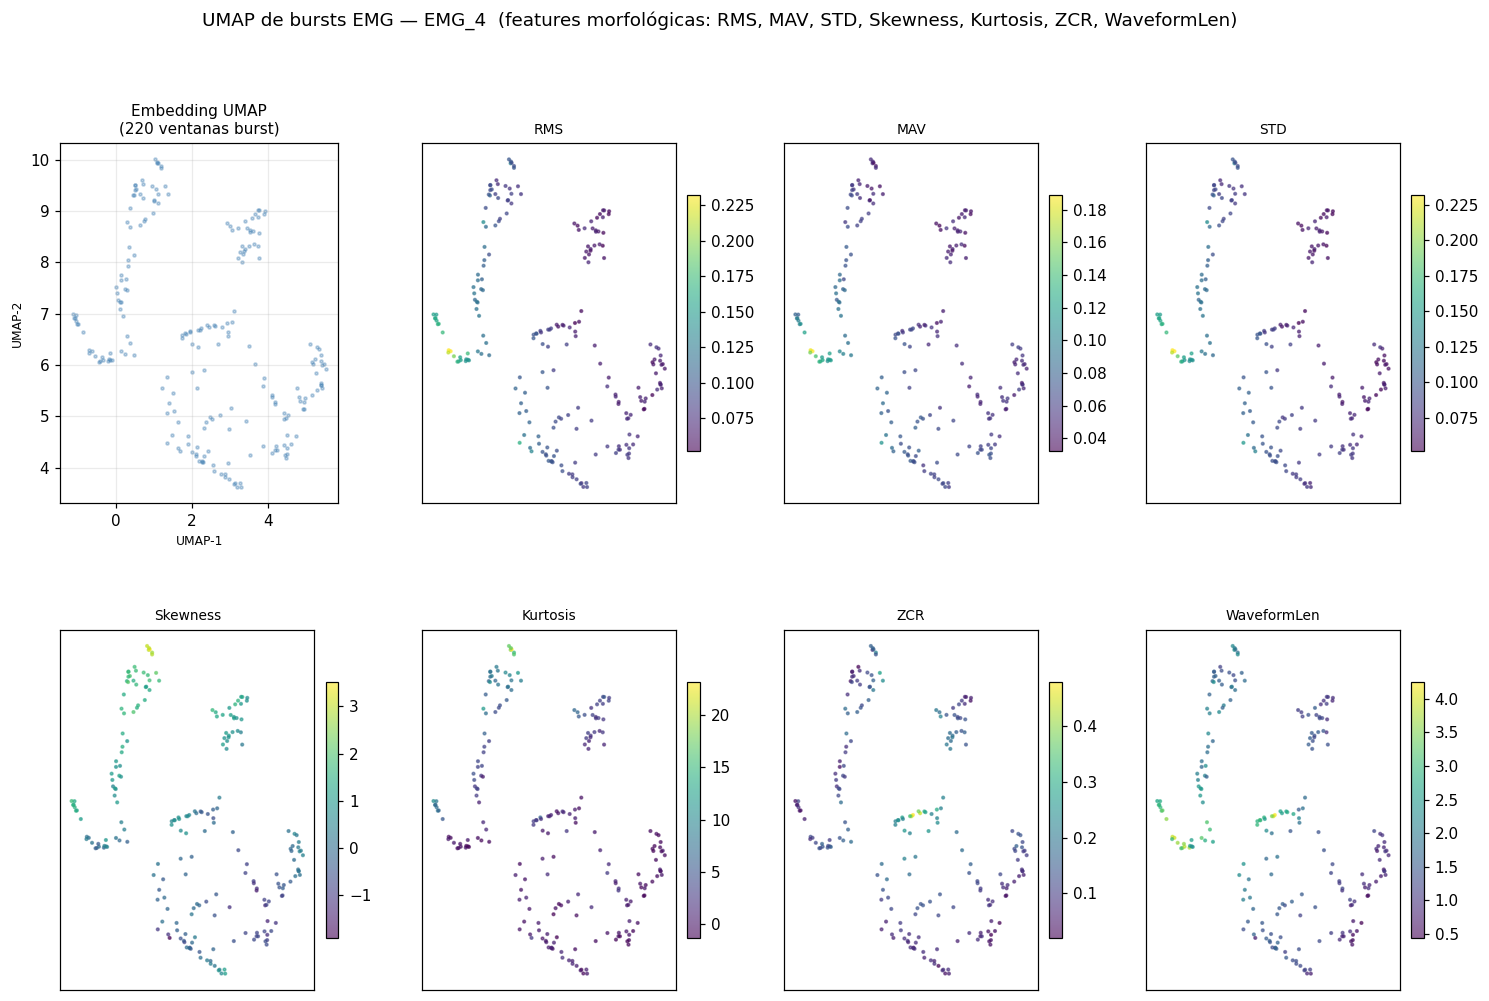

In [148]:
# ── UMAP sobre el subset burst con features reducidas ────────────────────────
import umap

# Parámetros UMAP
# - n_neighbors=30   : balance entre estructura local (clusters finos) y global
# - min_dist=0.0     : permite clusters compactos (ideal antes de HDBSCAN)
# - metric='euclidean': features ya estandarizadas
UMAP_NEIGHBORS = 30
UMAP_MIN_DIST  = 0.0
UMAP_SEED      = 42

reducer = umap.UMAP(
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_components=2,
    metric='euclidean',
    random_state=UMAP_SEED,
)
emb_burst = reducer.fit_transform(feat_burst_sc)   # (n_burst, 2)

print(f'UMAP — embedding 2D listo : shape={emb_burst.shape}')
print(f'  n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, seed={UMAP_SEED}')

# ── Visualización: embedding coloreado por cada feature reducida ─────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.30)

# Panel grande (esquina superior izq.): embedding sin color, solo densidad
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(emb_burst[:, 0], emb_burst[:, 1],
            s=4, alpha=0.35, color='steelblue', rasterized=True)
ax0.set_title(f'Embedding UMAP\n({len(emb_burst):,} ventanas burst)', fontsize=10)
ax0.set_xlabel('UMAP-1', fontsize=8)
ax0.set_ylabel('UMAP-2', fontsize=8)
ax0.grid(True, alpha=0.25)

# Resto de paneles: coloreados por cada feature reducida
panel_positions = [(0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
for (r, c), name, idx in zip(panel_positions, REDUCED_FEATURES, range(len(REDUCED_FEATURES))):
    ax = fig.add_subplot(gs[r, c])
    sc = ax.scatter(emb_burst[:, 0], emb_burst[:, 1],
                    c=feat_burst[:, idx], cmap='viridis',
                    s=3, alpha=0.6, rasterized=True)
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f'UMAP de bursts EMG — {EMG_CH}  '
    f'(features morfológicas: {", ".join(REDUCED_FEATURES)})',
    fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

  K |      Inercia |  Silhouette | Tamaños de cluster
----------------------------------------------------------------------
  2 |       1050.7 |       0.356 | 67, 153
  3 |        787.6 |       0.318 | 113, 40, 67
  4 |        636.1 |       0.333 | 36, 40, 106, 38
  5 |        534.1 |       0.316 | 105, 20, 25, 35, 35
  6 |        457.4 |       0.282 | 42, 17, 31, 36, 23, 71


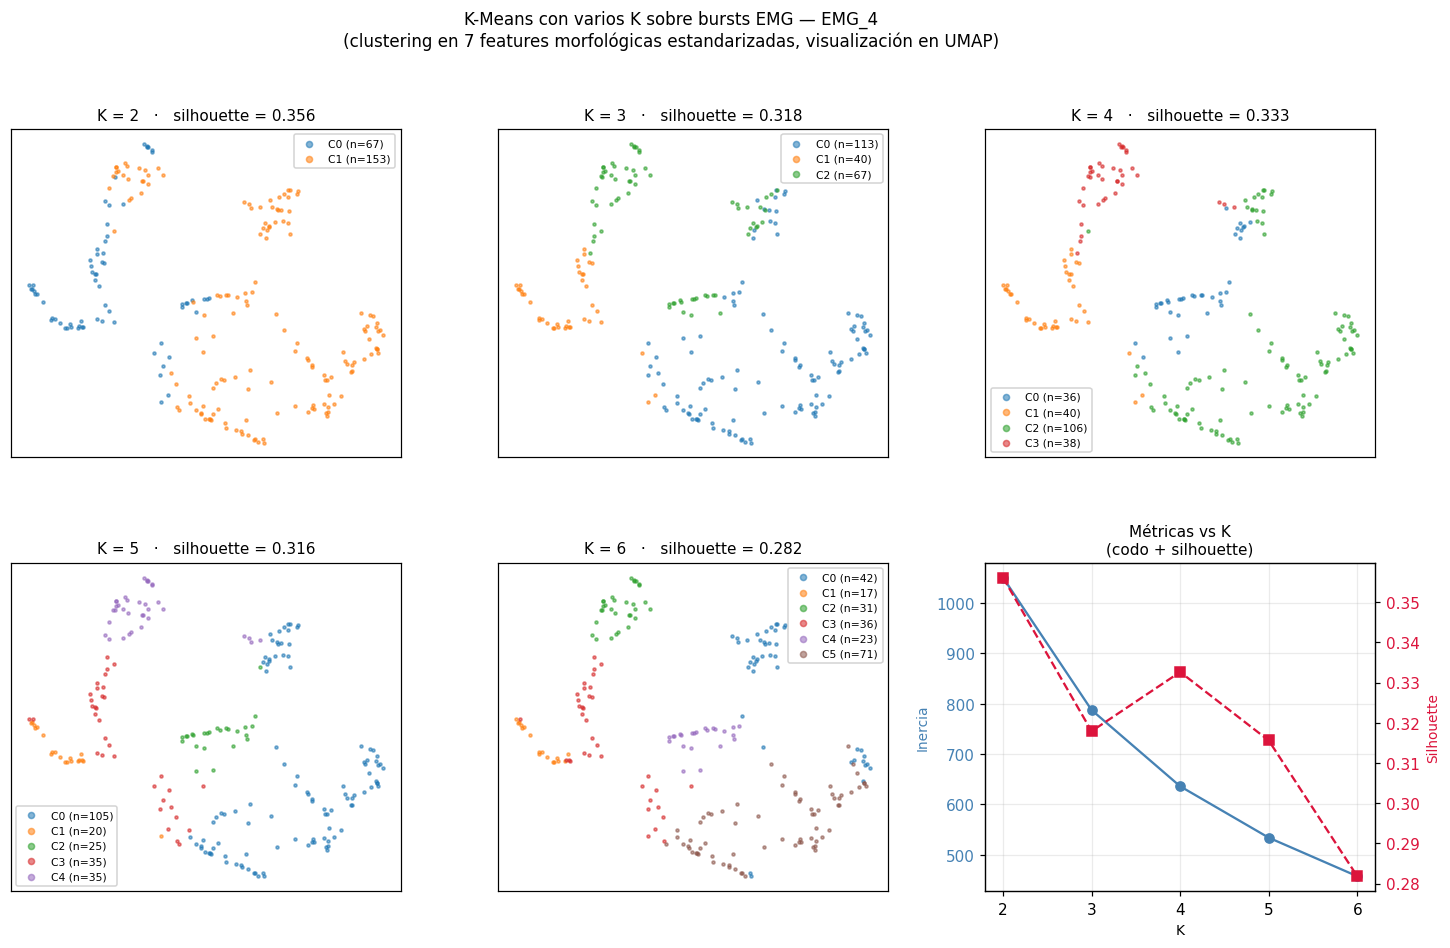

In [149]:
# ── K-Means con varios K sobre los bursts (features reducidas) ───────────────
from sklearn.metrics import silhouette_score

K_VALUES = [2, 3, 4, 5, 6]

# Calculamos K-Means en el espacio de features ESTANDARIZADAS (no en UMAP).
# UMAP lo usamos solo para visualizar el resultado.
kmeans_results = {}
for k in K_VALUES:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(feat_burst_sc)
    sil    = silhouette_score(feat_burst_sc, labels) if k > 1 else np.nan
    kmeans_results[k] = {'labels': labels, 'inertia': km.inertia_, 'silhouette': sil}

# ── Tabla resumen ─────────────────────────────────────────────────────────────
print(f'{"K":>3} | {"Inercia":>12} | {"Silhouette":>11} | Tamaños de cluster')
print('-' * 70)
for k in K_VALUES:
    res    = kmeans_results[k]
    sizes  = np.bincount(res['labels'])
    sizes_str = ', '.join(f'{s:,}' for s in sizes)
    print(f'{k:>3} | {res["inertia"]:>12.1f} | {res["silhouette"]:>11.3f} | {sizes_str}')

# ── Visualización: UMAP coloreado por cada K ─────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.32, wspace=0.25)

panel_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
for (r, c), k in zip(panel_positions, K_VALUES):
    ax     = fig.add_subplot(gs[r, c])
    labels = kmeans_results[k]['labels']
    sil    = kmeans_results[k]['silhouette']

    cmap = plt.get_cmap('tab10')
    for cl in range(k):
        m = labels == cl
        ax.scatter(emb_burst[m, 0], emb_burst[m, 1],
                   s=4, alpha=0.55, color=cmap(cl),
                   label=f'C{cl} (n={m.sum():,})', rasterized=True)

    ax.set_title(f'K = {k}   ·   silhouette = {sil:.3f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc='best', framealpha=0.85, markerscale=2)

# Panel 6: codo + silhouette
ax_metric = fig.add_subplot(gs[1, 2])
ax_metric.plot(K_VALUES, [kmeans_results[k]['inertia'] for k in K_VALUES],
               'o-', color='steelblue', label='Inercia')
ax_metric.set_xlabel('K', fontsize=9)
ax_metric.set_ylabel('Inercia', color='steelblue', fontsize=9)
ax_metric.tick_params(axis='y', labelcolor='steelblue')
ax_metric.grid(True, alpha=0.25)

ax_sil = ax_metric.twinx()
ax_sil.plot(K_VALUES, [kmeans_results[k]['silhouette'] for k in K_VALUES],
            's--', color='crimson', label='Silhouette')
ax_sil.set_ylabel('Silhouette', color='crimson', fontsize=9)
ax_sil.tick_params(axis='y', labelcolor='crimson')

ax_metric.set_title('Métricas vs K\n(codo + silhouette)', fontsize=10)

plt.suptitle(
    f'K-Means con varios K sobre bursts EMG — {EMG_CH}\n'
    f'(clustering en 7 features morfológicas estandarizadas, visualización en UMAP)',
    fontsize=11, y=1.00)
plt.tight_layout()
plt.show()

In [153]:
# ── Subplots 3D: K-Means con varios K sobre el mismo UMAP 3D ─────────────────
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Calcula UMAP 3D si aún no existe
if 'emb_burst_3d' not in globals():
    reducer_3d = umap.UMAP(
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        n_components=3,
        metric='euclidean',
        random_state=UMAP_SEED,
    )
    emb_burst_3d = reducer_3d.fit_transform(feat_burst_sc)
    print(f'UMAP 3D calculado: shape={emb_burst_3d.shape}')

K_VALUES_3D = [2, 3, 4, 5]
# ... (resto igual)
K_VALUES_3D = [2, 3, 4, 5]   # cuatro paneles → grilla 2x2

cmap_plotly = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
               '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}],
           [{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=[
        f'K = {k}   ·   silhouette = {kmeans_results[k]["silhouette"]:.3f}'
        for k in K_VALUES_3D
    ],
    horizontal_spacing=0.02,
    vertical_spacing=0.06,
)

panel_positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for (row, col), k in zip(panel_positions, K_VALUES_3D):
    labels_k = kmeans_results[k]['labels']

    for cl in range(k):
        m = labels_k == cl

        # Hover con tiempo + cluster
        hover = [
            f'<b>Ventana #{i}</b><br>'
            f't = {time_burst[i]:.2f} s<br>'
            f'Cluster: {cl}<br>'
            f'RMS: {feat_burst[i, 0]:.4f}  ·  Kurt: {feat_burst[i, 4]:.2f}'
            for i in np.where(m)[0]
        ]

        fig.add_trace(
            go.Scatter3d(
                x=emb_burst_3d[m, 0],
                y=emb_burst_3d[m, 1],
                z=emb_burst_3d[m, 2],
                mode='markers',
                marker=dict(size=2, color=cmap_plotly[cl], opacity=0.65),
                name=f'K={k} · C{cl}  (n={m.sum():,})',
                text=hover,
                hoverinfo='text',
                legendgroup=f'k{k}',
                showlegend=True,
            ),
            row=row, col=col,
        )

# Configuración común a todas las escenas 3D
scene_cfg = dict(
    xaxis_title='UMAP-1',
    yaxis_title='UMAP-2',
    zaxis_title='UMAP-3',
    bgcolor='white',
)
fig.update_layout(
    scene =scene_cfg,
    scene2=scene_cfg,
    scene3=scene_cfg,
    scene4=scene_cfg,
    title=dict(
        text=f'UMAP 3D de bursts EMG — comparación K-Means (K=2..5)<br>'
             f'<sup>{len(emb_burst_3d):,} ventanas burst · '
             f'{len(REDUCED_FEATURES)} features morfológicas estandarizadas</sup>',
        x=0.5,
    ),
    width=1100,
    height=900,
    legend=dict(itemsizing='constant', font=dict(size=9)),
    margin=dict(l=0, r=0, t=80, b=0),
)
fig.show()

UMAP 3D calculado: shape=(220, 3)


HDBSCAN sobre 220 bursts · 7 features
  min_cluster_size = 30,  min_samples = 5
  Clusters         : 2
  Ruido            : 113  (51.4 %)

 Cluster |      n |  RMS_medio |  Kurt_medio
--------------------------------------------------
   Ruido |    113 |     0.1057 |        3.63
      C0 |     76 |     0.0806 |        0.10
      C1 |     31 |     0.0736 |        4.02


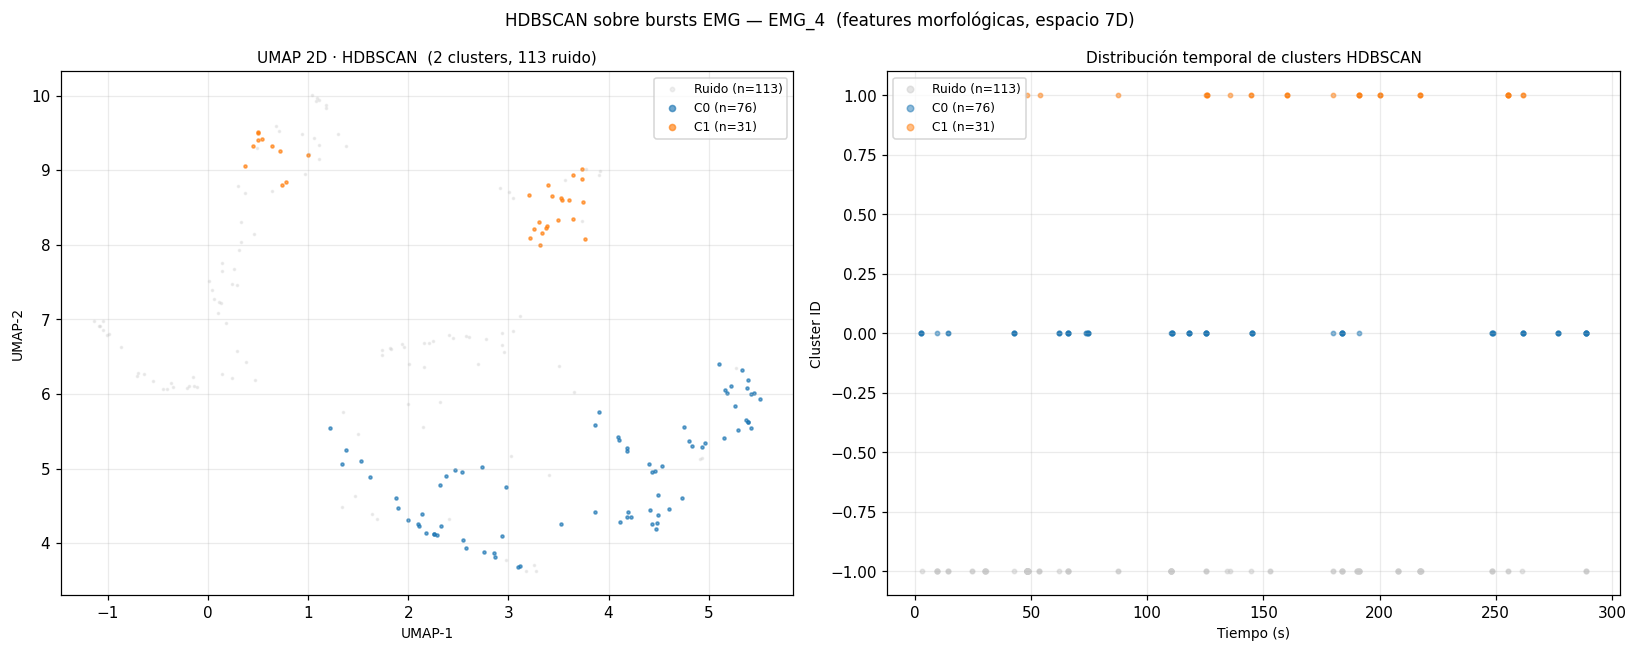

In [156]:
# ── HDBSCAN sobre los bursts (features reducidas) + visualización UMAP ───────
from sklearn.cluster import HDBSCAN

# HDBSCAN se entrena en el espacio de features ESTANDARIZADAS, no en UMAP
# (mismo criterio que con K-Means: UMAP es solo para visualizar)
HDB_MIN_CLUSTER = 30   # tamaño mínimo de cluster — ajustable según densidad
HDB_MIN_SAMPLES = 5    # cuán conservador es: más alto → más puntos como ruido

hdb = HDBSCAN(
    min_cluster_size=HDB_MIN_CLUSTER,
    min_samples=HDB_MIN_SAMPLES,
    metric='euclidean',
)
labels_hdb = hdb.fit_predict(feat_burst_sc)

# ── Resumen ──────────────────────────────────────────────────────────────────
unique_labels = sorted(set(labels_hdb))
n_clusters    = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise       = (labels_hdb == -1).sum()

print(f'HDBSCAN sobre {len(feat_burst_sc):,} bursts · {feat_burst_sc.shape[1]} features')
print(f'  min_cluster_size = {HDB_MIN_CLUSTER},  min_samples = {HDB_MIN_SAMPLES}')
print(f'  Clusters         : {n_clusters}')
print(f'  Ruido            : {n_noise:,}  ({n_noise / len(labels_hdb) * 100:.1f} %)')
print()
print(f'{"Cluster":>8} | {"n":>6} | {"RMS_medio":>10} | {"Kurt_medio":>11}')
print('-' * 50)
for cl in unique_labels:
    m   = labels_hdb == cl
    tag = 'Ruido' if cl == -1 else f'C{cl}'
    print(f'{tag:>8} | {m.sum():>6,} | '
          f'{feat_burst[m, 0].mean():>10.4f} | '
          f'{feat_burst[m, 4].mean():>11.2f}')

# ── Paleta: ruido en gris claro, clusters con tab10 ──────────────────────────
def hdb_color(cl):
    if cl == -1:
        return '#cccccc'
    return plt.get_cmap('tab10')(cl % 10)

# ── Visualización 2D (matplotlib) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: UMAP 2D coloreado por HDBSCAN
ax = axes[0]
for cl in unique_labels:
    m = labels_hdb == cl
    tag = 'Ruido' if cl == -1 else f'C{cl}'
    color = hdb_color(cl)
    color_mpl = color if isinstance(color, str) else color
    ax.scatter(emb_burst[m, 0], emb_burst[m, 1],
               s=4 if cl != -1 else 2,
               alpha=0.65 if cl != -1 else 0.3,
               color=color_mpl,
               label=f'{tag} (n={m.sum():,})',
               rasterized=True)
ax.set_title(f'UMAP 2D · HDBSCAN  ({n_clusters} clusters, {n_noise:,} ruido)', fontsize=10)
ax.set_xlabel('UMAP-1', fontsize=9)
ax.set_ylabel('UMAP-2', fontsize=9)
ax.legend(fontsize=8, markerscale=2, loc='best')
ax.grid(True, alpha=0.25)

# Panel B: línea temporal — cuándo aparece cada cluster
ax = axes[1]
for cl in unique_labels:
    m = labels_hdb == cl
    tag = 'Ruido' if cl == -1 else f'C{cl}'
    color = hdb_color(cl)
    y_pos = cl if cl != -1 else -1
    ax.scatter(time_burst[m], np.full(m.sum(), y_pos),
               s=8, alpha=0.5, color=color,
               label=f'{tag} (n={m.sum():,})')
ax.set_title('Distribución temporal de clusters HDBSCAN', fontsize=10)
ax.set_xlabel('Tiempo (s)', fontsize=9)
ax.set_ylabel('Cluster ID', fontsize=9)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, markerscale=1.5, loc='best')

plt.suptitle(f'HDBSCAN sobre bursts EMG — {EMG_CH}  '
             f'(features morfológicas, espacio 7D)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Visualización 3D interactiva (Plotly) ────────────────────────────────────
import plotly.graph_objects as go

fig3d = go.Figure()

cmap_plotly = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
               '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for cl in unique_labels:
    m = labels_hdb == cl
    tag = 'Ruido' if cl == -1 else f'Cluster {cl}'
    color = '#cccccc' if cl == -1 else cmap_plotly[cl % len(cmap_plotly)]

    hover = [
        f'<b>Ventana #{i}</b><br>'
        f't = {time_burst[i]:.2f} s<br>'
        f'{tag}<br>'
        f'RMS: {feat_burst[i, 0]:.4f}  ·  Kurt: {feat_burst[i, 4]:.2f}'
        for i in np.where(m)[0]
    ]

    fig3d.add_trace(go.Scatter3d(
        x=emb_burst_3d[m, 0],
        y=emb_burst_3d[m, 1],
        z=emb_burst_3d[m, 2],
        mode='markers',
        marker=dict(
            size=2 if cl != -1 else 1.5,
            color=color,
            opacity=0.7 if cl != -1 else 0.25,
        ),
        name=f'{tag} (n={m.sum():,})',
        text=hover,
        hoverinfo='text',
    ))

fig3d.update_layout(
    title=f'UMAP 3D · HDBSCAN sobre bursts EMG — {EMG_CH}<br>'
          f'<sup>{n_clusters} clusters · {n_noise:,} ventanas como ruido '
          f'({n_noise / len(labels_hdb) * 100:.1f} %)</sup>',
    scene=dict(
        xaxis_title='UMAP-1',
        yaxis_title='UMAP-2',
        zaxis_title='UMAP-3',
        bgcolor='white',
    ),
    width=900,
    height=700,
    legend=dict(itemsizing='constant'),
    margin=dict(l=0, r=0, t=70, b=0),
)
fig3d.show()

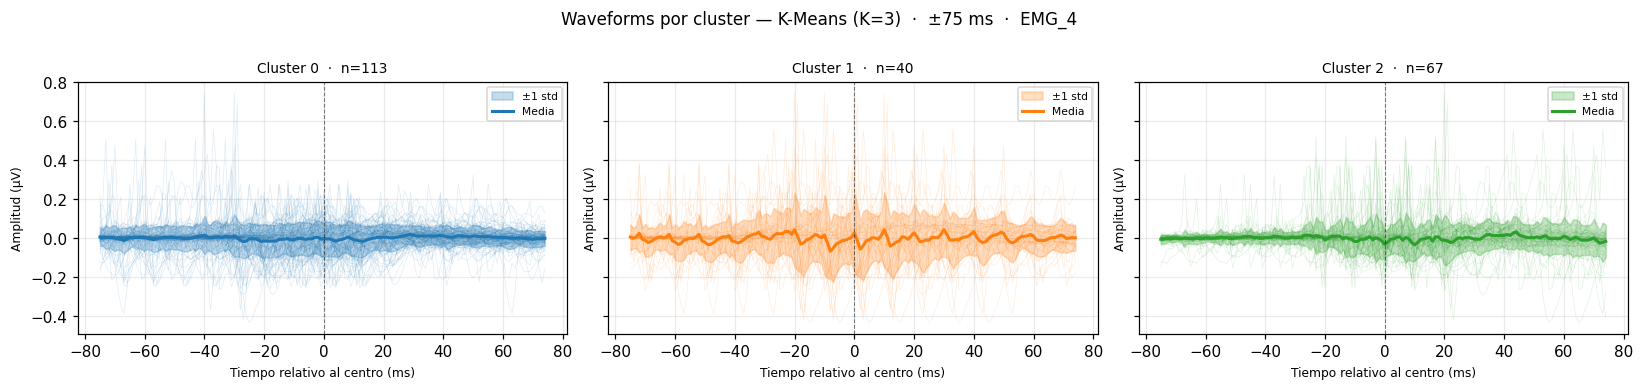

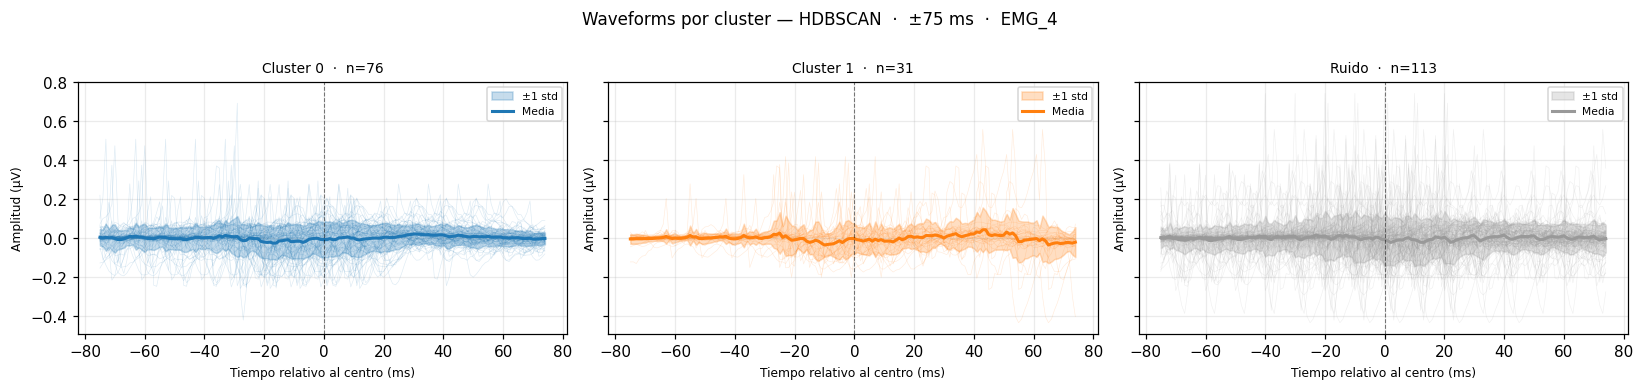

In [157]:
# ── Waveforms superpuestos por cluster (K-Means y HDBSCAN) ───────────────────
WIN_HALF  = int(0.075 * SRATE)              # ±75 ms alrededor del centro de la ventana
t_axis_ms = np.arange(-WIN_HALF, WIN_HALF) / SRATE * 1000
x_emg_c   = emg_raw - emg_raw.mean()        # señal EMG centrada

def plot_waveforms_by_cluster(labels, times, title, palette_fn,
                              max_traces=300, y_shared=True):
    """
    Grafica las waveforms de cada cluster en subplots separados.

    - labels     : array de cluster IDs (incluye -1 para ruido si aplica)
    - times      : tiempo central (s) de cada ventana
    - title      : título de la figura
    - palette_fn : función cl → color
    - max_traces : máximo de trazas individuales a dibujar por cluster (resto se omite)
    - y_shared   : si True, todos los subplots comparten escala Y
    """
    cluster_ids = sorted(set(labels))
    # Excluimos ruido del grid principal pero lo dibujamos al final si existe
    cluster_ids_main = [c for c in cluster_ids if c != -1]
    has_noise = -1 in cluster_ids
    n_panels  = len(cluster_ids_main) + (1 if has_noise else 0)

    if n_panels == 0:
        print(f'[{title}] Sin clusters para graficar.')
        return

    ncols = min(3, n_panels)
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5),
                             sharey=y_shared)
    axes = np.atleast_1d(axes).flatten()

    panel_order = cluster_ids_main + ([-1] if has_noise else [])

    for i, cl in enumerate(panel_order):
        ax       = axes[i]
        m        = labels == cl
        times_cl = times[m]
        color    = palette_fn(cl)
        tag      = 'Ruido' if cl == -1 else f'Cluster {cl}'

        # ── Recortar segmentos válidos ────────────────────────────────────────
        segs = []
        for ts in times_cl:
            c    = int(ts * SRATE)
            s, e = c - WIN_HALF, c + WIN_HALF
            if s >= 0 and e < len(x_emg_c):
                segs.append(x_emg_c[s:e])
        segs = np.array(segs) if segs else np.empty((0, 2 * WIN_HALF))

        # ── Subsample para evitar saturar la figura ──────────────────────────
        n_total_segs = len(segs)
        if n_total_segs > max_traces:
            idx = np.random.RandomState(42).choice(n_total_segs, max_traces, replace=False)
            segs_plot = segs[idx]
        else:
            segs_plot = segs

        # ── Dibujar trazas individuales en alpha bajo ────────────────────────
        for seg in segs_plot:
            ax.plot(t_axis_ms, seg, lw=0.4, alpha=0.15, color=color)

        # ── Media + banda de ±1 std (sobre TODAS las segs, no solo las plot) ─
        if len(segs) > 0:
            mean_seg = segs.mean(axis=0)
            std_seg  = segs.std(axis=0)
            ax.fill_between(t_axis_ms, mean_seg - std_seg, mean_seg + std_seg,
                            alpha=0.25, color=color, label='±1 std')
            ax.plot(t_axis_ms, mean_seg, lw=2.0, color=color, label='Media')

        ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
        ax.set_title(f'{tag}  ·  n={n_total_segs:,}'
                     + (f'  (mostrando {max_traces})' if n_total_segs > max_traces else ''),
                     fontsize=9)
        ax.set_xlabel('Tiempo relativo al centro (ms)', fontsize=8)
        ax.set_ylabel('Amplitud (µV)', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.25)

    for ax in axes[n_panels:]:
        ax.set_visible(False)

    plt.suptitle(title, fontsize=11, y=1.00)
    plt.tight_layout()
    plt.show()


# ═══════════════ K-Means: elige K para visualizar ════════════════════════════
K_TO_VIEW = 3
labels_km_view = kmeans_results[K_TO_VIEW]['labels']

def kmeans_palette(cl):
    return plt.get_cmap('tab10')(cl % 10)

plot_waveforms_by_cluster(
    labels_km_view, time_burst,
    title=f'Waveforms por cluster — K-Means (K={K_TO_VIEW})  ·  ±75 ms  ·  {EMG_CH}',
    palette_fn=kmeans_palette,
)

# ═══════════════ HDBSCAN ═════════════════════════════════════════════════════
def hdb_palette(cl):
    if cl == -1:
        return '#999999'
    return plt.get_cmap('tab10')(cl % 10)

plot_waveforms_by_cluster(
    labels_hdb, time_burst,
    title=f'Waveforms por cluster — HDBSCAN  ·  ±75 ms  ·  {EMG_CH}',
    palette_fn=hdb_palette,
)

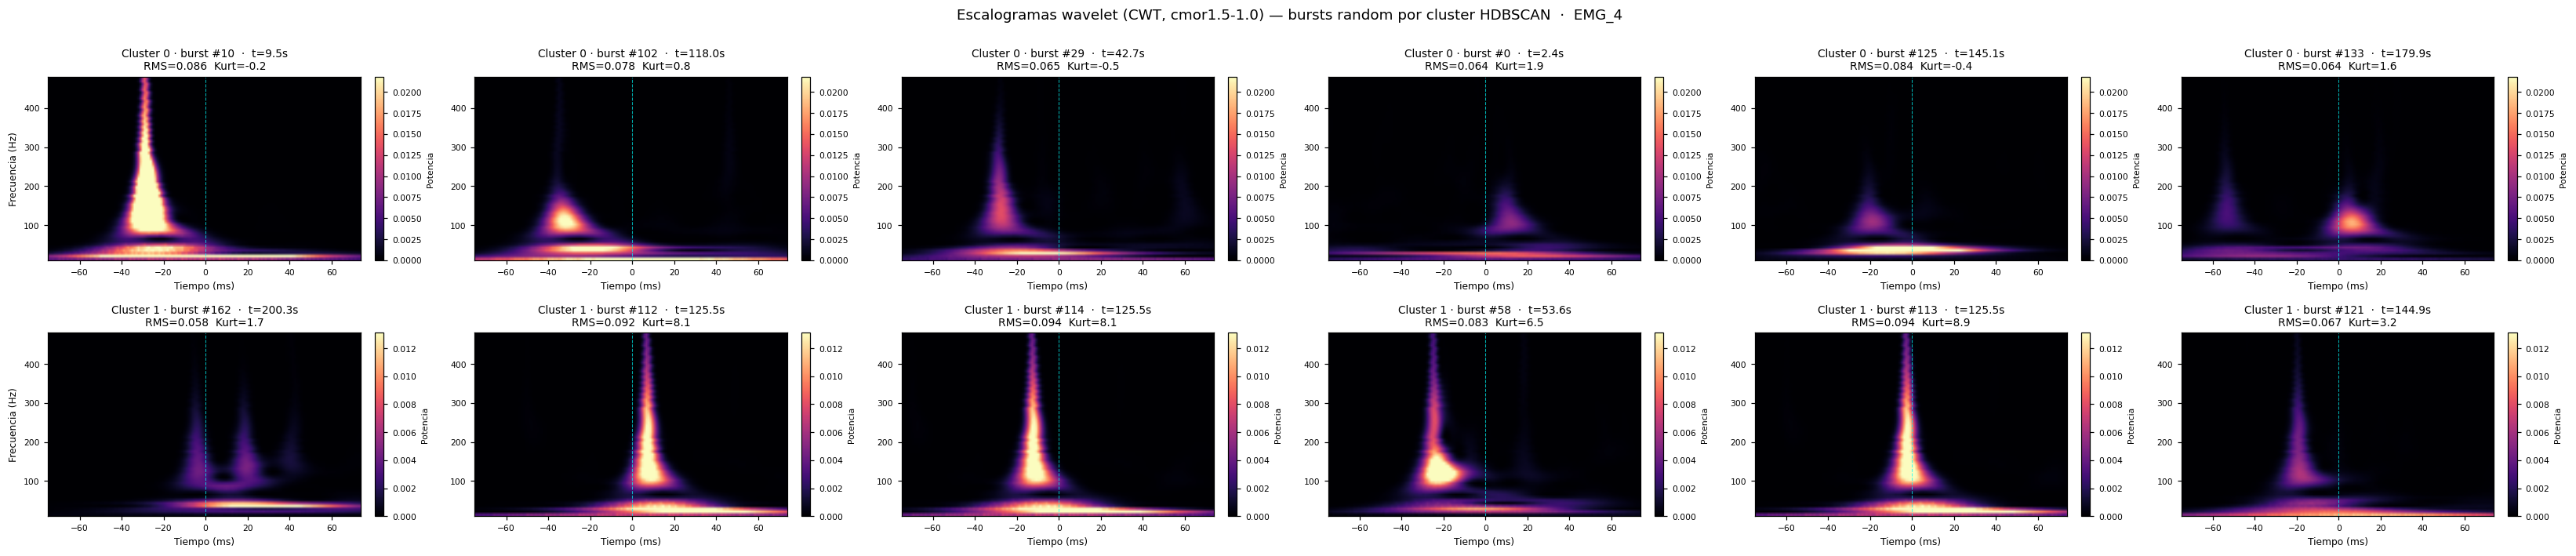

Wavelet      : cmor1.5-1.0
Ventana      : ±75 ms
Frecuencias  : 10 – 480 Hz  (64 escalas)
  Cluster 0: 6 bursts elegidos de 76 disponibles
  Cluster 1: 6 bursts elegidos de 31 disponibles


In [159]:
# ── Heatmaps Wavelet de bursts random por cluster HDBSCAN ────────────────────
import pywt

# ── Parámetros ────────────────────────────────────────────────────────────────
N_PER_CLUSTER = 6                          # bursts por cluster
WIN_HALF_W    = int(0.075 * SRATE)         # ±75 ms (mismo que waveforms)
WAVELET       = 'cmor1.5-1.0'              # Morlet complejo (continuo, ideal CWT)
N_SCALES      = 64                         # resolución frecuencial

# Frecuencias de interés en EMG: ~10 a 480 Hz (Nyquist=500)
FREQS         = np.linspace(10, 480, N_SCALES)
SCALES        = pywt.frequency2scale(WAVELET, FREQS / SRATE)

# ── Selección de bursts random por cluster (excluyendo ruido) ────────────────
rng = np.random.RandomState(42)
cluster_ids_hdb = sorted([cl for cl in set(labels_hdb) if cl != -1])
n_clusters_hdb  = len(cluster_ids_hdb)

if n_clusters_hdb == 0:
    raise ValueError('HDBSCAN no encontró clusters — solo ruido. Ajusta hyperparámetros.')

selected = {}   # cluster_id → lista de índices (en feat_burst / time_burst)
for cl in cluster_ids_hdb:
    idx_cl    = np.where(labels_hdb == cl)[0]
    # Filtrar solo los que tienen ventana completa (no chocan con bordes)
    valid = []
    for i in idx_cl:
        c = int(time_burst[i] * SRATE)
        if c - WIN_HALF_W >= 0 and c + WIN_HALF_W < len(emg_raw):
            valid.append(i)
    valid = np.array(valid)
    n_pick = min(N_PER_CLUSTER, len(valid))
    selected[cl] = rng.choice(valid, n_pick, replace=False)

# ── Figura: filas = clusters, columnas = bursts random ───────────────────────
nrows = n_clusters_hdb
ncols = N_PER_CLUSTER

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows),
                         squeeze=False)

x_emg_c   = emg_raw - emg_raw.mean()
t_axis_ms = np.arange(-WIN_HALF_W, WIN_HALF_W) / SRATE * 1000

vmax_global = 0  # para normalizar la escala de color entre subplots del mismo cluster

# Primera pasada: calcular escalogramas y guardar para normalización por cluster
scalograms = {}
for cl in cluster_ids_hdb:
    scalograms[cl] = []
    for i in selected[cl]:
        c   = int(time_burst[i] * SRATE)
        seg = x_emg_c[c - WIN_HALF_W : c + WIN_HALF_W]
        coeffs, _ = pywt.cwt(seg, SCALES, WAVELET, sampling_period=1.0 / SRATE)
        power = np.abs(coeffs) ** 2
        scalograms[cl].append((i, seg, power))

# Segunda pasada: graficar usando vmax por cluster
for row, cl in enumerate(cluster_ids_hdb):
    # Escala de color común dentro del cluster (mejora comparación intra-cluster)
    cluster_vmax = np.percentile(
        np.concatenate([p.flatten() for _, _, p in scalograms[cl]]), 99
    )

    for col, (i, seg, power) in enumerate(scalograms[cl]):
        ax = axes[row, col]
        im = ax.imshow(
            power,
            extent=[t_axis_ms[0], t_axis_ms[-1], FREQS[-1], FREQS[0]],
            aspect='auto',
            cmap='magma',
            vmin=0, vmax=cluster_vmax,
            interpolation='bilinear',
        )
        ax.invert_yaxis()
        ax.axvline(0, color='cyan', lw=0.7, ls='--', alpha=0.7)
        ax.set_title(
            f'Cluster {cl} · burst #{i}  ·  t={time_burst[i]:.1f}s\n'
            f'RMS={feat_burst[i, 0]:.3f}  Kurt={feat_burst[i, 4]:.1f}',
            fontsize=9,
        )
        ax.set_xlabel('Tiempo (ms)', fontsize=8)
        if col == 0:
            ax.set_ylabel('Frecuencia (Hz)', fontsize=8)
        ax.tick_params(labelsize=7)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label('Potencia', fontsize=7)

plt.suptitle(
    f'Escalogramas wavelet (CWT, {WAVELET}) — bursts random por cluster HDBSCAN  ·  {EMG_CH}',
    fontsize=12, y=1.00,
)
plt.tight_layout()
plt.show()

# ── Resumen ──────────────────────────────────────────────────────────────────
print(f'Wavelet      : {WAVELET}')
print(f'Ventana      : ±{int(WIN_HALF_W / SRATE * 1000)} ms')
print(f'Frecuencias  : {FREQS[0]:.0f} – {FREQS[-1]:.0f} Hz  ({N_SCALES} escalas)')
for cl in cluster_ids_hdb:
    print(f'  Cluster {cl}: {len(selected[cl])} bursts elegidos de {(labels_hdb == cl).sum():,} disponibles')